# DATA 620 — Assignment Week 5 Part 2: Document Classification

**Course:** DATA 620 — Web Analytics  
**Assignment:** Document Classification  

**Group Members:**

- Crystal Quezada
- Nana Kwasi Danquah
- Muhammad Suffyan Khan

This notebook develops a document-classification system using consumer complaint narratives from the Consumer Financial Protection Bureau (CFPB) Consumer Complaint Database. Each complaint narrative represents a text document that has already been assigned to a financial product category.

The goal of this assignment is to train machine-learning models on previously classified complaint narratives and evaluate how accurately they predict the product category of new, previously unseen complaints. This project follows the assignment's encouraged approach of using a different collection of already classified documents rather than the standard Spambase dataset.

## Assignment Objectives

In this notebook, we answer the following questions:

1. What types of consumer complaint documents are included in the selected dataset?
2. How are the complaint documents distributed across the selected financial product categories?
3. What words and phrases are most distinctive within each complaint category?
4. How can TF-IDF be used to convert complaint narratives into numerical features?
5. How accurately can machine-learning models classify previously unseen complaint documents?
6. Which classification model provides the strongest overall performance?
7. How do the models compare using accuracy, precision, recall, and F1-score?
8. Which financial product categories are most frequently confused by the models?
9. Which words and phrases are most influential in distinguishing the complaint categories?

## Data Sources

- [CFPB Consumer Complaint Database](https://www.consumerfinance.gov/data-research/consumer-complaints/)
- [CFPB Consumer Complaint Database — Compressed CSV Download](https://files.consumerfinance.gov/ccdb/complaints.csv.zip)
- [Scikit-learn: Working with Text Data](https://scikit-learn.org/stable/tutorial/text_analytics/working_with_text_data.html)

The complaint data is obtained from the official CFPB Consumer Complaint Database bulk CSV download. Because the complete database is too large to include in the GitHub repository, it is stored locally and processed in manageable chunks.

A fixed, balanced, and cleaned sample of the complaint narratives is saved in the repository. This allows the notebook to produce reproducible results without requiring the complete raw database each time it is executed.

## Video Presentation

A short video presentation explaining the document-classification process and results is available here:

**Video Link:** To be added after recording.

## Objective

The objective of this assignment is to build and compare machine-learning models that classify consumer complaint narratives into their correct financial product categories. The analysis uses complaint documents that have already been labeled by the CFPB as training data and withholds a portion of the documents as an unseen test set.

The complaint narratives will be prepared and transformed into numerical TF-IDF features. Multiple classification algorithms will then be trained and evaluated using accuracy, precision, recall, F1-score, classification reports, and confusion matrices.

The analysis will also identify words and phrases that distinguish the selected product categories and examine examples of correctly and incorrectly classified test documents.

## Research Question

**How accurately can machine-learning classifiers use consumer complaint narratives to predict the financial product category of previously unseen complaints, and which model provides the best performance across the selected categories?**

## Importing Libraries

This section imports the Python libraries required for data preparation, visualization, natural language processing, model training, and performance evaluation.

The analysis uses Python's `zipfile` module and `pandas` to read the official compressed CFPB dataset in manageable chunks. `pandas` and `NumPy` support data preparation and numerical operations, while `Matplotlib` provides data visualizations.

Scikit-learn supplies the TF-IDF text representation, training and testing utilities, classification algorithms, and model evaluation metrics.

A fixed random state is established to make the sampling process, training-test split, and model results reproducible.

In [1]:
# Standard library imports
import zipfile
from pathlib import Path

# Data manipulation
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Notebook display utility
from IPython.display import display

# Reproducibility setting
RANDOM_STATE = 42

# Improve the readability of displayed tables
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)
pd.set_option(
    "display.float_format",
    lambda value: f"{value:,.4f}"
)

# Global visualization settings
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

# Reusable visualization colors
main_color = "#4C78A8"
accent_color = "#F58518"
green_color = "#54A24B"
red_color = "#E45756"
purple_color = "#B279A2"
gray_color = "#BAB0AC"

palette = [
    "#4C78A8",
    "#F58518",
    "#54A24B",
    "#E45756",
    "#72B7B2",
    "#B279A2",
    "#FF9DA6",
    "#9D755D",
    "#BAB0AC",
    "#59A14F"
]

print("All required libraries were imported successfully.")

All required libraries were imported successfully.


## Dataset File Configuration

This section defines the locations of the raw and processed data files used in the analysis.

The notebook first looks for the fixed processed complaint sample in the `data/processed` directory. When this file is available, it can be used directly without the much larger raw download. If the processed sample is unavailable, the notebook looks for the official compressed CFPB dataset in `data/raw` and uses it to recreate the balanced sample.

Only the processed sample is intended to be committed to the GitHub repository.

In [2]:
# Define the raw and processed data directories
RAW_DIR = Path("data/raw")
PROCESSED_DIR = Path("data/processed")

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

PROCESSED_FILE = (
    PROCESSED_DIR /
    "cfpb_complaints_sample.csv"
)

RAW_ZIP_FILE = None
RAW_CSV_MEMBER = None

if PROCESSED_FILE.exists():

    print("Processed CFPB dataset successfully located.")
    print(f"Processed dataset: {PROCESSED_FILE}")
    print(
        "The raw ZIP file is not required because the "
        "processed dataset snapshot is available."
    )

else:

    if not RAW_DIR.exists():
        raise FileNotFoundError(
            "Neither the processed dataset nor the raw data "
            "directory was found."
        )

    zip_candidates = [
        file_path
        for file_path in RAW_DIR.iterdir()
        if file_path.is_file()
        and zipfile.is_zipfile(file_path)
    ]

    if not zip_candidates:
        raise FileNotFoundError(
            "The processed dataset was not found, and no valid "
            "CFPB ZIP file was found in data/raw."
        )

    RAW_ZIP_FILE = sorted(zip_candidates)[0]

    with zipfile.ZipFile(
        RAW_ZIP_FILE,
        mode="r"
    ) as archive:

        csv_members = [
            member
            for member in archive.namelist()
            if member.lower().endswith(".csv")
            and not member.startswith("__MACOSX")
        ]

        if not csv_members:
            raise FileNotFoundError(
                "The ZIP archive does not contain a CSV file."
            )

        RAW_CSV_MEMBER = max(
            csv_members,
            key=lambda member:
            archive.getinfo(member).file_size
        )

        compressed_size_mb = (
            RAW_ZIP_FILE.stat().st_size /
            (1024 ** 2)
        )

        uncompressed_size_mb = (
            archive.getinfo(
                RAW_CSV_MEMBER
            ).file_size /
            (1024 ** 2)
        )

    print("Raw CFPB dataset successfully located.")
    print(f"ZIP file: {RAW_ZIP_FILE}")
    print(
        f"CSV file inside archive: "
        f"{RAW_CSV_MEMBER}"
    )
    print(
        f"Compressed size: "
        f"{compressed_size_mb:,.2f} MB"
    )
    print(
        f"Uncompressed CSV size: "
        f"{uncompressed_size_mb:,.2f} MB"
    )

print(f"Processed dataset location: {PROCESSED_FILE}")

Processed CFPB dataset successfully located.
Processed dataset: data\processed\cfpb_complaints_sample.csv
The raw ZIP file is not required because the processed dataset snapshot is available.
Processed dataset location: data\processed\cfpb_complaints_sample.csv


## Inspecting the Dataset Structure

This section previews the available complaint dataset before the analysis begins. When the fixed processed sample is available, the notebook loads a small preview from that file. Otherwise, it inspects the original compressed CFPB CSV before creating the processed sample.

The preview verifies that the fields required for identification, date filtering, descriptive analysis, document classification, and target labeling are available.

In [3]:
# Source fields required from the original CFPB dataset
REQUIRED_SOURCE_COLUMNS = [
    "Complaint ID",
    "Date received",
    "Product",
    "Issue",
    "Consumer complaint narrative"
]

# Explain the role of each source field
source_structure = pd.DataFrame(
    {
        "Source Field": REQUIRED_SOURCE_COLUMNS,
        "Role in Analysis": [
            "Unique identifier used for duplicate detection",
            "Used to restrict complaints to the selected date range",
            "Existing product category used as the target label",
            "Retained for descriptive analysis but excluded from model inputs",
            "Raw complaint document used as the predictive input"
        ]
    }
)

In [4]:
if RAW_ZIP_FILE is not None:

    with zipfile.ZipFile(
        RAW_ZIP_FILE,
        mode="r"
    ) as archive:

        with archive.open(
            RAW_CSV_MEMBER
        ) as csv_file:

            raw_preview = pd.read_csv(
                csv_file,
                nrows=5,
                low_memory=False
            )

    missing_source_columns = [
        column
        for column in REQUIRED_SOURCE_COLUMNS
        if column not in raw_preview.columns
    ]

    if missing_source_columns:
        raise KeyError(
            "The raw CFPB dataset is missing the "
            f"following fields: {missing_source_columns}"
        )

    print("Raw dataset structure verified successfully.")
    print(
        f"Total columns in the source dataset: "
        f"{len(raw_preview.columns)}"
    )

    display(source_structure)
    display(
        raw_preview[
            REQUIRED_SOURCE_COLUMNS
        ]
    )

else:

    processed_preview = pd.read_csv(
        PROCESSED_FILE,
        nrows=5,
        dtype={"complaint_id": "string"}
    )

    print(
        "Processed dataset structure verified successfully."
    )
    print(
        f"Total columns in the processed dataset: "
        f"{len(processed_preview.columns)}"
    )

    display(processed_preview)

Processed dataset structure verified successfully.
Total columns in the processed dataset: 5


,complaint_id,date_received,product,issue,narrative
0,18537313,2026-01-07,Mortgage,Struggling to pay mortgage,I am filing a NEW complaint regarding Fifth Third Banks ongoing foreclosure activity and servicing conduct after Fif...
1,8639367,2024-03-27,Credit card,Closing your account,Citibank closed my credit card without any warning or notice to me. They did not even provide me with closure notice...
2,15233301,2025-08-12,Credit reporting or other personal consumer reports,Improper use of your report,This letter is a formal notice of dispute under the Fair Credit Reporting Act ( FCRA ) regarding inaccurately report...
3,9011478,2024-05-15,Credit card,Problem when making payments,On the XXXX of XXXX I called Citi Bank customers service because the bank tried to access my bank for XXXX payment w...
4,7900699,2023-11-24,Credit card,Closing your account,"XXXX XXXX XXXX XXXX XXXX XXXX XXXX, Florida XXXX AMERICAN EXPRESS XXXX XXXX XXXX XXXX XXXX, TX XXXX ( XXXX ) XXXX RE..."


## Analysis Scope and Sampling Configuration

This section defines the financial product categories, date range, and sampling settings used to construct the document-classification dataset.

Five product categories are selected to create a meaningful multiclass classification problem. The analysis includes complaints received from January 1, 2023 through June 30, 2026. A balanced sample of 2,000 unique complaint narratives per category will produce a final dataset of 10,000 documents.

The complete compressed dataset will be read in chunks to limit memory usage. A larger candidate pool will first be retained for each category so that missing and duplicate narratives can be removed before the final balanced sample is created.

In [5]:
# Financial product categories used as target labels
SELECTED_PRODUCTS = [
    "Credit reporting or other personal consumer reports",
    "Debt collection",
    "Credit card",
    "Mortgage",
    "Checking or savings account"
]

# Fixed analysis period
DATE_RECEIVED_MIN = pd.Timestamp(
    "2023-01-01",
    tz="UTC"
)

# Exclusive upper boundary includes complaints through June 30, 2026
DATE_RECEIVED_MAX_EXCLUSIVE = pd.Timestamp(
    "2026-07-01",
    tz="UTC"
)

# Balanced sampling settings
SAMPLES_PER_PRODUCT = 2_000
CANDIDATE_POOL_PER_PRODUCT = 10_000
CHUNK_SIZE = 100_000

# Expected final dataset size
EXPECTED_DOCUMENTS = (
    len(SELECTED_PRODUCTS) *
    SAMPLES_PER_PRODUCT
)

# Display the selected project configuration
configuration_summary = pd.DataFrame(
    {
        "Setting": [
            "Selected product categories",
            "Documents per category",
            "Expected final documents",
            "Analysis start date",
            "Analysis end date",
            "CSV chunk size",
            "Candidate pool per category"
        ],
        "Value": [
            len(SELECTED_PRODUCTS),
            f"{SAMPLES_PER_PRODUCT:,}",
            f"{EXPECTED_DOCUMENTS:,}",
            DATE_RECEIVED_MIN.strftime("%Y-%m-%d"),
            (
                DATE_RECEIVED_MAX_EXCLUSIVE
                - pd.Timedelta(days=1)
            ).strftime("%Y-%m-%d"),
            f"{CHUNK_SIZE:,}",
            f"{CANDIDATE_POOL_PER_PRODUCT:,}"
        ]
    }
)

display(configuration_summary)

print("Selected product categories:")

for category_number, product in enumerate(
    SELECTED_PRODUCTS,
    start=1
):
    print(f"{category_number}. {product}")

,Setting,Value
0,Selected product categories,5
1,Documents per category,"2,000"
2,Expected final documents,"10,000"
3,Analysis start date,2023-01-01
4,Analysis end date,2026-06-30
5,CSV chunk size,"100,000"
6,Candidate pool per category,"10,000"


Selected product categories:
1. Credit reporting or other personal consumer reports
2. Debt collection
3. Credit card
4. Mortgage
5. Checking or savings account


## Creating the Balanced Complaint Dataset

The complete CFPB complaint database is processed in manageable chunks. Records are retained only when they fall within the selected date range, belong to one of the five selected product categories, and contain a consumer complaint narrative.

Duplicate complaint IDs and duplicate narratives are removed. A deterministic sampling procedure then selects 2,000 documents from each category, producing a balanced dataset of 10,000 complaint documents.

The processed sample is saved in the `data/processed` directory so that later notebook executions can load the smaller fixed dataset directly.

In [6]:
# Simplified names used in the processed dataset
COLUMN_RENAMES = {
    "Complaint ID": "complaint_id",
    "Date received": "date_received",
    "Product": "product",
    "Issue": "issue",
    "Consumer complaint narrative": "narrative"
}

PROCESSED_COLUMNS = [
    "complaint_id",
    "date_received",
    "product",
    "issue",
    "narrative"
]


def validate_processed_sample(data):
    missing_columns = [
        column
        for column in PROCESSED_COLUMNS
        if column not in data.columns
    ]

    if missing_columns:
        raise KeyError(
            "The processed dataset is missing columns: "
            f"{missing_columns}"
        )

    category_counts = (
        data["product"]
        .value_counts()
        .reindex(SELECTED_PRODUCTS, fill_value=0)
    )

    if len(data) != EXPECTED_DOCUMENTS:
        raise ValueError(
            f"Expected {EXPECTED_DOCUMENTS:,} documents, "
            f"but found {len(data):,}."
        )

    if not category_counts.eq(SAMPLES_PER_PRODUCT).all():
        raise ValueError(
            "The processed dataset is not balanced across "
            "the selected product categories."
        )

    if data["narrative"].isna().any():
        raise ValueError(
            "The processed dataset contains missing narratives."
        )

    if data["narrative"].duplicated().any():
        raise ValueError(
            "The processed dataset contains duplicate narratives."
        )


if PROCESSED_FILE.exists():

    # Load the fixed sample if it was previously created
    complaints = pd.read_csv(
        PROCESSED_FILE,
        dtype={"complaint_id": "string"}
    )

    complaints["date_received"] = pd.to_datetime(
        complaints["date_received"],
        errors="coerce",
        utc=True
    )

    processing_status = (
        "Loaded the existing processed dataset."
    )

else:

    # Maintain a limited candidate pool for each product category
    candidate_pools = {
        product: None
        for product in SELECTED_PRODUCTS
    }

    rows_scanned = 0
    eligible_documents = 0

    with zipfile.ZipFile(
        RAW_ZIP_FILE,
        mode="r"
    ) as archive:

        with archive.open(
            RAW_CSV_MEMBER
        ) as csv_file:

            chunk_reader = pd.read_csv(
                csv_file,
                usecols=REQUIRED_SOURCE_COLUMNS,
                dtype={"Complaint ID": "string"},
                chunksize=CHUNK_SIZE,
                low_memory=False
            )

            for chunk_number, chunk in enumerate(
                chunk_reader,
                start=1
            ):
                rows_scanned += len(chunk)

                chunk = chunk.rename(
                    columns=COLUMN_RENAMES
                )

                # Convert dates to a consistent UTC format
                chunk["date_received"] = pd.to_datetime(
                    chunk["date_received"],
                    errors="coerce",
                    utc=True
                )

                # Standardize complaint narratives
                chunk["narrative"] = (
                    chunk["narrative"]
                    .astype("string")
                    .str.replace(
                        r"\s+",
                        " ",
                        regex=True
                    )
                    .str.strip()
                )

                chunk["complaint_id"] = (
                    chunk["complaint_id"]
                    .astype("string")
                    .str.strip()
                )

                # Retain eligible complaint documents
                chunk = chunk.loc[
                    (
                        chunk["product"].isin(
                            SELECTED_PRODUCTS
                        )
                        & chunk["date_received"].ge(
                            DATE_RECEIVED_MIN
                        )
                        & chunk["date_received"].lt(
                            DATE_RECEIVED_MAX_EXCLUSIVE
                        )
                        & chunk["complaint_id"].notna()
                        & chunk["narrative"].notna()
                        & chunk["narrative"].str.len().gt(0)
                    ),
                    PROCESSED_COLUMNS
                ].copy()

                if chunk.empty:
                    continue

                eligible_documents += len(chunk)

                # Create a deterministic sampling priority
                hash_input = (
                    chunk["complaint_id"].fillna("")
                    + "|"
                    + chunk["narrative"].fillna("")
                    + f"|{RANDOM_STATE}"
                )

                chunk["_priority"] = (
                    pd.util.hash_pandas_object(
                        hash_input,
                        index=False
                    )
                    .astype("uint64")
                )

                # Update each category's limited candidate pool
                for product in SELECTED_PRODUCTS:

                    product_rows = chunk.loc[
                        chunk["product"].eq(product)
                    ]

                    if product_rows.empty:
                        continue

                    existing_pool = candidate_pools[
                        product
                    ]

                    if existing_pool is None:
                        combined_pool = product_rows
                    else:
                        combined_pool = pd.concat(
                            [
                                existing_pool,
                                product_rows
                            ],
                            ignore_index=True
                        )

                    candidate_pools[product] = (
                        combined_pool
                        .drop_duplicates(
                            subset="complaint_id",
                            keep="first"
                        )
                        .drop_duplicates(
                            subset="narrative",
                            keep="first"
                        )
                        .nsmallest(
                            CANDIDATE_POOL_PER_PRODUCT,
                            "_priority"
                        )
                        .reset_index(drop=True)
                    )

                if (
                    chunk_number == 1
                    or chunk_number % 10 == 0
                ):
                    print(
                        f"Processed {rows_scanned:,} "
                        "raw records..."
                    )

    # Combine the candidate documents
    candidate_documents = pd.concat(
        [
            pool
            for pool in candidate_pools.values()
            if pool is not None
        ],
        ignore_index=True
    )

    # Remove duplicates across all categories
    candidate_documents = (
        candidate_documents
        .sort_values("_priority")
        .drop_duplicates(
            subset="complaint_id",
            keep="first"
        )
        .drop_duplicates(
            subset="narrative",
            keep="first"
        )
        .reset_index(drop=True)
    )

    available_counts = (
        candidate_documents["product"]
        .value_counts()
        .reindex(
            SELECTED_PRODUCTS,
            fill_value=0
        )
    )

    insufficient_categories = {
        product: int(count)
        for product, count in available_counts.items()
        if count < SAMPLES_PER_PRODUCT
    }

    if insufficient_categories:
        raise ValueError(
            "Insufficient unique narratives were found for: "
            f"{insufficient_categories}"
        )

    # Select exactly 2,000 documents per category
    balanced_samples = []

    for product in SELECTED_PRODUCTS:

        product_sample = (
            candidate_documents.loc[
                candidate_documents[
                    "product"
                ].eq(product)
            ]
            .nsmallest(
                SAMPLES_PER_PRODUCT,
                "_priority"
            )
        )

        balanced_samples.append(product_sample)

    complaints = (
        pd.concat(
            balanced_samples,
            ignore_index=True
        )
        .drop(columns="_priority")
        .sample(
            frac=1,
            random_state=RANDOM_STATE
        )
        .reset_index(drop=True)
    )

    validate_processed_sample(complaints)

    # Save dates in ISO format
    complaints_to_save = complaints.copy()

    complaints_to_save["date_received"] = (
        complaints_to_save["date_received"]
        .dt.strftime("%Y-%m-%d")
    )

    complaints_to_save.to_csv(
        PROCESSED_FILE,
        index=False,
        encoding="utf-8"
    )

    processing_status = (
        "Created and saved the processed dataset."
    )


# Final validation
validate_processed_sample(complaints)

class_counts = (
    complaints["product"]
    .value_counts()
    .reindex(SELECTED_PRODUCTS)
    .rename_axis("Product Category")
    .reset_index(name="Documents")
)

print()
print(processing_status)
print(f"Rows scanned: {rows_scanned:,}" if "rows_scanned" in locals() else "")
print(f"Processed file: {PROCESSED_FILE}")
print(
    f"Final dimensions: "
    f"{complaints.shape[0]:,} rows × "
    f"{complaints.shape[1]} columns"
)
print(
    "Duplicate narratives: "
    f"{complaints['narrative'].duplicated().sum():,}"
)

display(class_counts)


Loaded the existing processed dataset.

Processed file: data\processed\cfpb_complaints_sample.csv
Final dimensions: 10,000 rows × 5 columns
Duplicate narratives: 0


,Product Category,Documents
0,Credit reporting or other personal consumer reports,2000
1,Debt collection,2000
2,Credit card,2000
3,Mortgage,2000
4,Checking or savings account,2000


## Processed Dataset Overview

This section examines the structure and quality of the processed complaint dataset before beginning exploratory text analysis.

The overview verifies the number of records and variables, date coverage, number of target categories, missing values, and duplicate records. A small sample of the processed complaint documents is also displayed.

In [7]:
# Ensure the date field uses a consistent datetime format
complaints["date_received"] = pd.to_datetime(
    complaints["date_received"],
    errors="coerce",
    utc=True
)

# Create a general dataset summary
dataset_overview = pd.DataFrame(
    {
        "Measure": [
            "Total documents",
            "Total variables",
            "Product categories",
            "Earliest complaint date",
            "Latest complaint date",
            "Missing narratives",
            "Duplicate complaint IDs",
            "Duplicate narratives"
        ],
        "Value": [
            f"{len(complaints):,}",
            complaints.shape[1],
            complaints["product"].nunique(),
            complaints["date_received"].min().strftime(
                "%Y-%m-%d"
            ),
            complaints["date_received"].max().strftime(
                "%Y-%m-%d"
            ),
            f"{complaints['narrative'].isna().sum():,}",
            f"{complaints['complaint_id'].duplicated().sum():,}",
            f"{complaints['narrative'].duplicated().sum():,}"
        ]
    }
)

# Summarize missing values by variable
missing_values_summary = pd.DataFrame(
    {
        "Variable": complaints.columns,
        "Missing Values": [
            complaints[column].isna().sum()
            for column in complaints.columns
        ],
        "Missing Percentage": [
            (
                complaints[column].isna().mean()
                * 100
            )
            for column in complaints.columns
        ]
    }
)

missing_values_summary[
    "Missing Percentage"
] = missing_values_summary[
    "Missing Percentage"
].round(2)

print("Processed dataset overview:")
display(dataset_overview)

print("Missing-value summary:")
display(missing_values_summary)

print("Sample processed complaint documents:")
display(
    complaints[
        [
            "complaint_id",
            "date_received",
            "product",
            "issue",
            "narrative"
        ]
    ].head(5)
)

Processed dataset overview:


,Measure,Value
0,Total documents,"10,000"
1,Total variables,5
2,Product categories,5
3,Earliest complaint date,2023-01-01
4,Latest complaint date,2026-06-17
5,Missing narratives,0
6,Duplicate complaint IDs,0
7,Duplicate narratives,0


Missing-value summary:


,Variable,Missing Values,Missing Percentage
0,complaint_id,0,0.0000
1,date_received,0,0.0000
2,product,0,0.0000
3,issue,0,0.0000
4,narrative,0,0.0000


Sample processed complaint documents:


,complaint_id,date_received,product,issue,narrative
0,18537313,2026-01-07 00:00:00+00:00,Mortgage,Struggling to pay mortgage,I am filing a NEW complaint regarding Fifth Third Banks ongoing foreclosure activity and servicing conduct after Fif...
1,8639367,2024-03-27 00:00:00+00:00,Credit card,Closing your account,Citibank closed my credit card without any warning or notice to me. They did not even provide me with closure notice...
2,15233301,2025-08-12 00:00:00+00:00,Credit reporting or other personal consumer reports,Improper use of your report,This letter is a formal notice of dispute under the Fair Credit Reporting Act ( FCRA ) regarding inaccurately report...
3,9011478,2024-05-15 00:00:00+00:00,Credit card,Problem when making payments,On the XXXX of XXXX I called Citi Bank customers service because the bank tried to access my bank for XXXX payment w...
4,7900699,2023-11-24 00:00:00+00:00,Credit card,Closing your account,"XXXX XXXX XXXX XXXX XXXX XXXX XXXX, Florida XXXX AMERICAN EXPRESS XXXX XXXX XXXX XXXX XXXX, TX XXXX ( XXXX ) XXXX RE..."


## Distribution of Complaint Documents by Product Category

Before training the classification models, the distribution of documents across the target product categories is examined.

A balanced target distribution prevents categories with substantially more documents from dominating the training process. It also makes model performance easier to compare across categories.

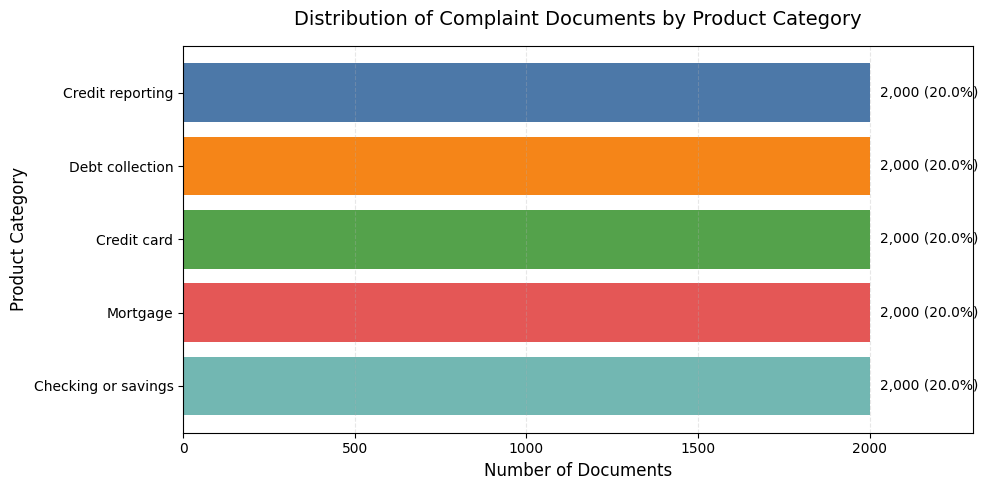

In [8]:
# Calculate document counts and percentages by product category
class_distribution = (
    complaints["product"]
    .value_counts()
    .reindex(SELECTED_PRODUCTS)
    .rename_axis("product")
    .reset_index(name="documents")
)

class_distribution["percentage"] = (
    class_distribution["documents"]
    / class_distribution["documents"].sum()
    * 100
)

# Shorter labels improve readability in the visualization
display_labels = {
    "Credit reporting or other personal consumer reports":
        "Credit reporting",
    "Debt collection":
        "Debt collection",
    "Credit card":
        "Credit card",
    "Mortgage":
        "Mortgage",
    "Checking or savings account":
        "Checking or savings"
}

plot_labels = (
    class_distribution["product"]
    .map(display_labels)
)

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(
    plot_labels,
    class_distribution["documents"],
    color=palette[:5]
)

ax.invert_yaxis()

ax.set_title(
    "Distribution of Complaint Documents by Product Category",
    pad=15
)

ax.set_xlabel("Number of Documents")
ax.set_ylabel("Product Category")

ax.set_xlim(
    0,
    class_distribution["documents"].max() * 1.15
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.30
)

# Display counts and percentages beside each bar
for bar, count, percentage in zip(
    bars,
    class_distribution["documents"],
    class_distribution["percentage"]
):
    ax.text(
        bar.get_width() + 30,
        bar.get_y() + bar.get_height() / 2,
        f"{count:,} ({percentage:.1f}%)",
        va="center"
    )

plt.tight_layout()
plt.show()

### Interpretation

The visualization confirms that each of the five financial product categories contains exactly 2,000 complaint documents, representing 20% of the final dataset.

Because there is no majority category, each product contributes equally to model training and evaluation. This reduces the risk that a classifier will achieve a high overall accuracy simply by favoring the most common class. However, precision, recall, and F1-score will still be examined separately for each category to identify differences in classification performance.

## Complaint Narrative Length by Product Category

Document length may vary across financial product categories and can influence the number of words available for classification. This section calculates the word and character counts for every complaint narrative and summarizes typical document length within each category.

A horizontal box plot compares the distribution of word counts. Extreme outliers are hidden from the visualization so that differences in the central portions of the distributions remain readable; however, all documents remain in the dataset and will be used in later analysis.

,product,documents,mean_words,median_words,minimum_words,maximum_words
0,Credit reporting or other personal consumer reports,2000,212.3000,147.0000,6,3549
1,Debt collection,2000,190.2000,126.0000,2,5678
2,Credit card,2000,231.2000,172.0000,8,5911
3,Mortgage,2000,303.5000,227.5000,9,5227
4,Checking or savings account,2000,224.4000,167.0000,5,3676


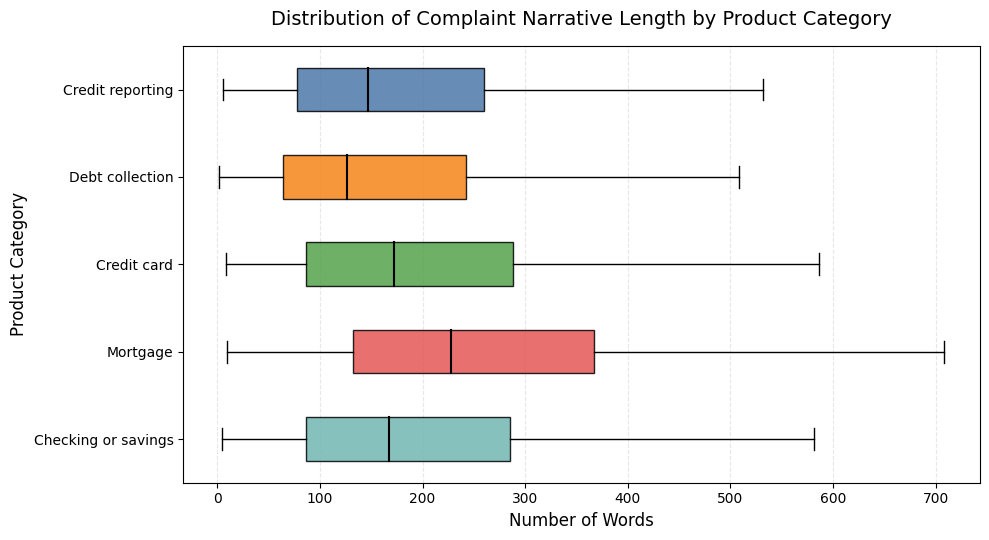

In [9]:
# Calculate narrative-length measures
complaints["word_count"] = (
    complaints["narrative"]
    .str.split()
    .str.len()
)

complaints["character_count"] = (
    complaints["narrative"]
    .str.len()
)

# Summarize word counts by product category
length_summary = (
    complaints
    .groupby("product")
    .agg(
        documents=("narrative", "size"),
        mean_words=("word_count", "mean"),
        median_words=("word_count", "median"),
        minimum_words=("word_count", "min"),
        maximum_words=("word_count", "max")
    )
    .reindex(SELECTED_PRODUCTS)
    .reset_index()
)

length_summary[
    ["mean_words", "median_words"]
] = length_summary[
    ["mean_words", "median_words"]
].round(1)

display(length_summary)

# Prepare category-specific word-count data
word_count_groups = [
    complaints.loc[
        complaints["product"].eq(product),
        "word_count"
    ]
    for product in SELECTED_PRODUCTS
]

short_category_labels = [
    "Credit reporting",
    "Debt collection",
    "Credit card",
    "Mortgage",
    "Checking or savings"
]

fig, ax = plt.subplots(figsize=(10, 5.5))

boxplot = ax.boxplot(
    word_count_groups,
    vert=False,
    labels=short_category_labels,
    showfliers=False,
    patch_artist=True,
    medianprops={
        "color": "black",
        "linewidth": 1.5
    }
)

# Apply the notebook palette to the boxes
for box, color in zip(
    boxplot["boxes"],
    palette[:5]
):
    box.set_facecolor(color)
    box.set_alpha(0.85)

ax.invert_yaxis()

ax.set_title(
    "Distribution of Complaint Narrative Length by Product Category",
    pad=15
)

ax.set_xlabel("Number of Words")
ax.set_ylabel("Product Category")

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.30
)

plt.tight_layout()
plt.show()

### Interpretation

Complaint length differs noticeably across product categories. Mortgage complaints are the longest, with a median of approximately 228 words and an average of 304 words. Debt collection complaints are the shortest, with a median of 126 words and an average of 190 words.

For every category, the mean is higher than the median, and some narratives contain several thousand words. This indicates right-skewed distributions in which most complaints are moderately sized but a smaller number are exceptionally long. The visualization hides extreme outliers only to improve readability; all complaint documents remain available for classification.

These differences suggest that some categories provide more textual information than others. TF-IDF will help reduce the influence of document length by emphasizing the relative importance of words and phrases rather than relying only on their raw counts.

## Preparing the Training and Test Sets

The complaint documents are divided into separate training and test sets before TF-IDF features or classification models are created.

The training set contains 80% of the documents and will be used to learn vocabulary patterns and train the classifiers. The remaining 20% forms an unseen test set used for comparative evaluation of the trained classification models.

A stratified split preserves the balanced product distribution, resulting in 1,600 training documents and 400 test documents from each category. Complaint IDs and narratives are also checked to confirm that no document appears in both sets.

In [10]:
# Retain only the fields required for model development
model_data = complaints[
    [
        "complaint_id",
        "product",
        "narrative"
    ]
].copy()

# Create stratified training and test datasets
train_data, test_data = train_test_split(
    model_data,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=model_data["product"]
)

# Reset indexes for easier inspection
train_data = train_data.reset_index(drop=True)
test_data = test_data.reset_index(drop=True)

# Separate text documents and target labels
X_train = train_data["narrative"]
X_test = test_data["narrative"]

y_train = train_data["product"]
y_test = test_data["product"]

# Summarize category counts in each dataset
split_summary = pd.DataFrame(
    {
        "Total Documents": (
            model_data["product"]
            .value_counts()
            .reindex(SELECTED_PRODUCTS)
        ),
        "Training Documents": (
            y_train
            .value_counts()
            .reindex(SELECTED_PRODUCTS)
        ),
        "Test Documents": (
            y_test
            .value_counts()
            .reindex(SELECTED_PRODUCTS)
        )
    }
)

split_summary.index.name = "Product Category"

# Check for accidental overlap between datasets
overlapping_ids = len(
    set(train_data["complaint_id"])
    .intersection(test_data["complaint_id"])
)

overlapping_narratives = len(
    set(train_data["narrative"])
    .intersection(test_data["narrative"])
)

print(
    f"Training set: {len(train_data):,} documents "
    f"({len(train_data) / len(model_data):.0%})"
)

print(
    f"Test set: {len(test_data):,} documents "
    f"({len(test_data) / len(model_data):.0%})"
)

print(
    f"Overlapping complaint IDs: "
    f"{overlapping_ids:,}"
)

print(
    f"Overlapping narratives: "
    f"{overlapping_narratives:,}"
)

display(split_summary)

Training set: 8,000 documents (80%)
Test set: 2,000 documents (20%)
Overlapping complaint IDs: 0
Overlapping narratives: 0


,Total Documents,Training Documents,Test Documents
Product Category,,,
Credit reporting or other personal consumer reports,2000,1600,400
Debt collection,2000,1600,400
Credit card,2000,1600,400
Mortgage,2000,1600,400
Checking or savings account,2000,1600,400


## Text Preparation and TF-IDF Feature Extraction

Machine-learning classifiers cannot process raw text directly, so the complaint narratives must be converted into numerical features.

Before feature extraction, common CFPB redaction placeholders such as `XXXX` and web addresses are removed because they do not describe the financial product associated with a complaint. Extra whitespace is also standardized.

The training documents are then transformed using Term Frequency–Inverse Document Frequency (TF-IDF). TF-IDF assigns greater importance to words and phrases that are informative within particular documents while reducing the influence of terms that occur throughout the corpus.

The vectorizer includes both individual words and two-word phrases, known as unigrams and bigrams. English stop words are removed, terms appearing in fewer than three training documents are excluded, and the vocabulary is limited to 30,000 features.

To prevent data leakage, the TF-IDF vocabulary and feature weights are learned exclusively from the training documents. The fitted vectorizer is then used to transform the unseen test documents.

In [11]:
def prepare_narrative_text(text_series):

    return (
        text_series
        .astype("string")
        # Remove common CFPB anonymization placeholders
        .str.replace(
            r"(?i)\bX{2,}\b",
            " ",
            regex=True
        )
        # Remove web addresses
        .str.replace(
            r"(?i)https?://\S+|www\.\S+",
            " ",
            regex=True
        )
        # Standardize whitespace
        .str.replace(
            r"\s+",
            " ",
            regex=True
        )
        .str.strip()
    )


# Prepare training and test narratives separately
X_train_clean = prepare_narrative_text(X_train)
X_test_clean = prepare_narrative_text(X_test)

# Confirm that text preparation did not create empty documents
empty_training_documents = (
    X_train_clean.str.len().eq(0).sum()
)

empty_test_documents = (
    X_test_clean.str.len().eq(0).sum()
)

if empty_training_documents > 0:
    raise ValueError(
        "Text preparation created empty training documents."
    )

if empty_test_documents > 0:
    raise ValueError(
        "Text preparation created empty test documents."
    )

# Configure the TF-IDF text representation
tfidf_vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95,
    max_features=30_000,
    sublinear_tf=True,
    dtype=np.float32
)

# Learn the vocabulary only from the training documents
X_train_tfidf = tfidf_vectorizer.fit_transform(
    X_train_clean
)

# Apply the learned representation to the unseen test documents
X_test_tfidf = tfidf_vectorizer.transform(
    X_test_clean
)

# Support both newer and older scikit-learn versions
if hasattr(
    tfidf_vectorizer,
    "get_feature_names_out"
):
    feature_names = (
        tfidf_vectorizer
        .get_feature_names_out()
    )
else:
    feature_names = np.array(
        tfidf_vectorizer
        .get_feature_names()
    )

# Summarize the resulting document-term matrices
tfidf_summary = pd.DataFrame(
    {
        "Measure": [
            "Training documents",
            "Test documents",
            "TF-IDF features",
            "Maximum allowed features",
            "Average active features per training document",
            "Average active features per test document",
            "Empty training documents",
            "Empty test documents"
        ],
        "Value": [
            f"{X_train_tfidf.shape[0]:,}",
            f"{X_test_tfidf.shape[0]:,}",
            f"{X_train_tfidf.shape[1]:,}",
            f"{tfidf_vectorizer.max_features:,}",
            (
                f"{X_train_tfidf.getnnz(axis=1).mean():,.1f}"
            ),
            (
                f"{X_test_tfidf.getnnz(axis=1).mean():,.1f}"
            ),
            f"{empty_training_documents:,}",
            f"{empty_test_documents:,}"
        ]
    }
)

print(
    "Training TF-IDF matrix shape: "
    f"{X_train_tfidf.shape}"
)

print(
    "Test TF-IDF matrix shape: "
    f"{X_test_tfidf.shape}"
)

display(tfidf_summary)

Training TF-IDF matrix shape: (8000, 30000)
Test TF-IDF matrix shape: (2000, 30000)


,Measure,Value
0,Training documents,"8,000"
1,Test documents,"2,000"
2,TF-IDF features,"30,000"
3,Maximum allowed features,"30,000"
4,Average active features per training document,100.2
5,Average active features per test document,96.0
6,Empty training documents,0
7,Empty test documents,0


## Distinctive Words and Phrases by Product Category

This section examines the words and two-word phrases that most strongly distinguish each financial product category in the training corpus.

For every TF-IDF feature, the average weight within one category is compared with its average weight across the other four categories. Features with the largest positive differences are treated as the most distinctive terms for that category.

Only the training documents are used in this analysis. The unseen test documents remain separate and do not influence feature interpretation or model development.

In [12]:
# Number of distinctive terms displayed for each category
TOP_TERMS_PER_CATEGORY = 12

# Exclude features that contain no alphabetic characters
feature_has_letters = (
    pd.Series(feature_names)
    .str.contains(
        r"[A-Za-z]",
        regex=True
    )
    .to_numpy()
)

distinctive_term_records = []

for product in SELECTED_PRODUCTS:

    # Identify training documents belonging to the current category
    category_mask = (
        y_train.eq(product)
        .to_numpy()
    )

    # Calculate average TF-IDF weight inside the category
    category_mean = np.asarray(
        X_train_tfidf[
            category_mask
        ].mean(axis=0)
    ).ravel()

    # Calculate average TF-IDF weight across all other categories
    other_categories_mean = np.asarray(
        X_train_tfidf[
            ~category_mask
        ].mean(axis=0)
    ).ravel()

    # Larger positive values indicate greater category distinctiveness
    distinctiveness_scores = (
        category_mean
        - other_categories_mean
    )

    # Exclude numeric-only features
    distinctiveness_scores[
        ~feature_has_letters
    ] = -np.inf

    top_feature_indexes = np.argsort(
        distinctiveness_scores
    )[-TOP_TERMS_PER_CATEGORY:][::-1]

    for rank, feature_index in enumerate(
        top_feature_indexes,
        start=1
    ):
        distinctive_term_records.append(
            {
                "Product Category": product,
                "Rank": rank,
                "Term": feature_names[
                    feature_index
                ],
                "Distinctiveness Score":
                    distinctiveness_scores[
                        feature_index
                    ]
            }
        )

distinctive_terms = pd.DataFrame(
    distinctive_term_records
)

# Shorter names make the table and visualizations easier to read
short_product_names = {
    "Credit reporting or other personal consumer reports":
        "Credit reporting",
    "Debt collection":
        "Debt collection",
    "Credit card":
        "Credit card",
    "Mortgage":
        "Mortgage",
    "Checking or savings account":
        "Checking or savings"
}

distinctive_terms["Short Category"] = (
    distinctive_terms[
        "Product Category"
    ].map(short_product_names)
)

# Display the ranked terms in a compact comparison table
distinctive_terms_table = (
    distinctive_terms
    .pivot(
        index="Rank",
        columns="Short Category",
        values="Term"
    )
    .reindex(
        columns=[
            "Credit reporting",
            "Debt collection",
            "Credit card",
            "Mortgage",
            "Checking or savings"
        ]
    )
)

distinctive_terms_table.columns.name = (
    "Product Category"
)

display(distinctive_terms_table)

Product Category,Credit reporting,Debt collection,Credit card,Mortgage,Checking or savings
Rank,,,,,
1,report,debt,card,mortgage,bank
2,credit report,collection,credit card,loan,funds
3,reporting,validation,charges,escrow,money
4,inquiries,collect,charge,home,account
5,accounts,collector,credit,payment,checking
6,credit,debt collection,synchrony,insurance,deposit
7,consumer,fdcpa,capital,payments,transactions
8,information,debt collector,cards,property,check
9,inaccurate,report,charged,foreclosure,checking account


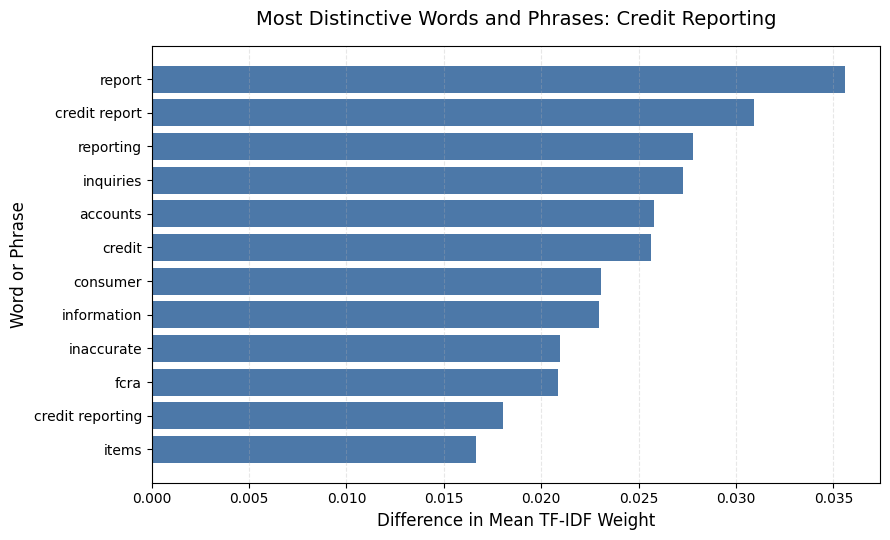

In [13]:
credit_reporting_terms = (
    distinctive_terms.loc[
        distinctive_terms["Product Category"].eq(
            "Credit reporting or other personal consumer reports"
        )
    ]
    .sort_values(
        "Distinctiveness Score",
        ascending=True
    )
)

fig, ax = plt.subplots(figsize=(9, 5.5))

ax.barh(
    credit_reporting_terms["Term"],
    credit_reporting_terms["Distinctiveness Score"],
    color=main_color
)

ax.set_title(
    "Most Distinctive Words and Phrases: Credit Reporting",
    pad=15
)

ax.set_xlabel("Difference in Mean TF-IDF Weight")
ax.set_ylabel("Word or Phrase")

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.30
)

plt.tight_layout()
plt.show()

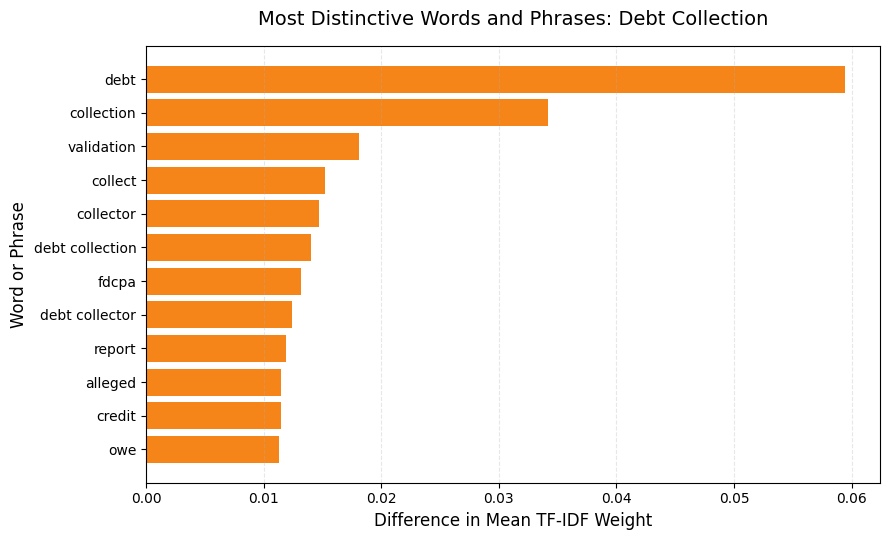

In [14]:
debt_collection_terms = (
    distinctive_terms.loc[
        distinctive_terms["Product Category"].eq(
            "Debt collection"
        )
    ]
    .sort_values(
        "Distinctiveness Score",
        ascending=True
    )
)

fig, ax = plt.subplots(figsize=(9, 5.5))

ax.barh(
    debt_collection_terms["Term"],
    debt_collection_terms["Distinctiveness Score"],
    color=accent_color
)

ax.set_title(
    "Most Distinctive Words and Phrases: Debt Collection",
    pad=15
)

ax.set_xlabel("Difference in Mean TF-IDF Weight")
ax.set_ylabel("Word or Phrase")

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.30
)

plt.tight_layout()
plt.show()

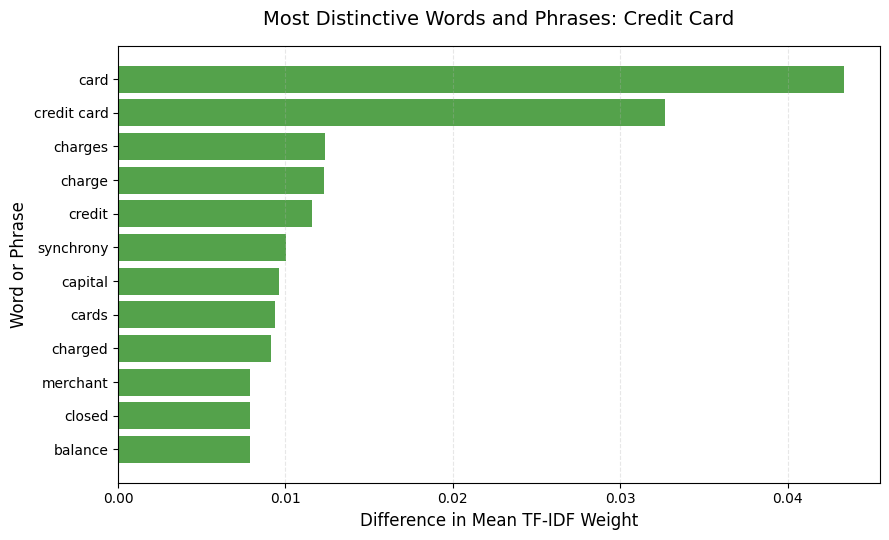

In [15]:
credit_card_terms = (
    distinctive_terms.loc[
        distinctive_terms["Product Category"].eq(
            "Credit card"
        )
    ]
    .sort_values(
        "Distinctiveness Score",
        ascending=True
    )
)

fig, ax = plt.subplots(figsize=(9, 5.5))

ax.barh(
    credit_card_terms["Term"],
    credit_card_terms["Distinctiveness Score"],
    color=green_color
)

ax.set_title(
    "Most Distinctive Words and Phrases: Credit Card",
    pad=15
)

ax.set_xlabel("Difference in Mean TF-IDF Weight")
ax.set_ylabel("Word or Phrase")

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.30
)

plt.tight_layout()
plt.show()

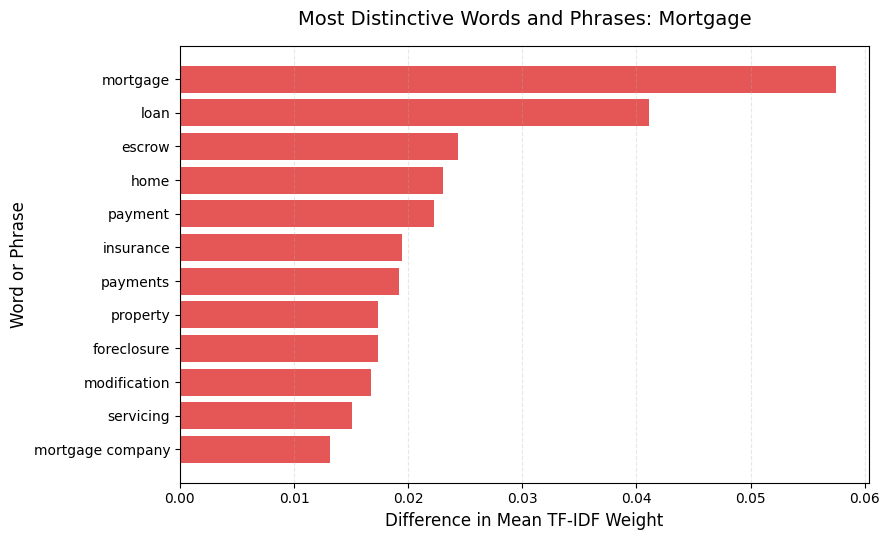

In [16]:
mortgage_terms = (
    distinctive_terms.loc[
        distinctive_terms["Product Category"].eq(
            "Mortgage"
        )
    ]
    .sort_values(
        "Distinctiveness Score",
        ascending=True
    )
)

fig, ax = plt.subplots(figsize=(9, 5.5))

ax.barh(
    mortgage_terms["Term"],
    mortgage_terms["Distinctiveness Score"],
    color=red_color
)

ax.set_title(
    "Most Distinctive Words and Phrases: Mortgage",
    pad=15
)

ax.set_xlabel("Difference in Mean TF-IDF Weight")
ax.set_ylabel("Word or Phrase")

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.30
)

plt.tight_layout()
plt.show()

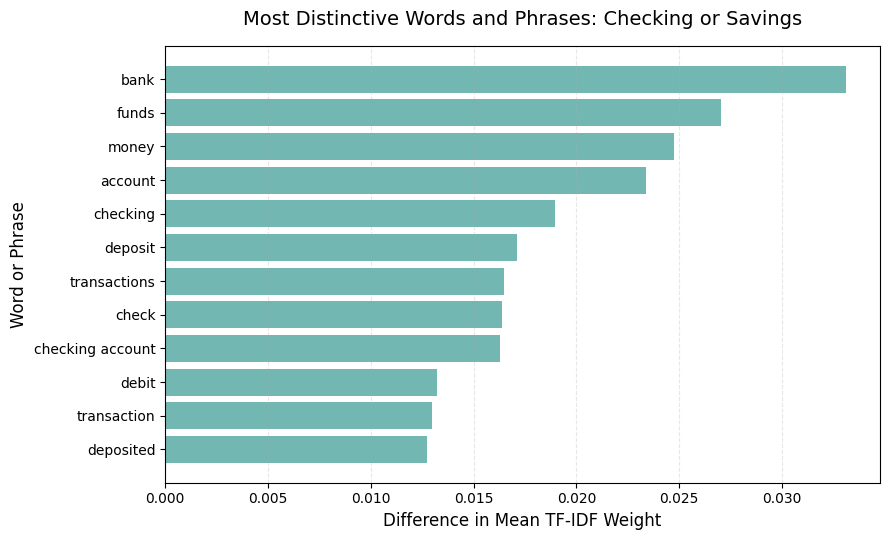

In [17]:
checking_savings_terms = (
    distinctive_terms.loc[
        distinctive_terms["Product Category"].eq(
            "Checking or savings account"
        )
    ]
    .sort_values(
        "Distinctiveness Score",
        ascending=True
    )
)

fig, ax = plt.subplots(figsize=(9, 5.5))

ax.barh(
    checking_savings_terms["Term"],
    checking_savings_terms["Distinctiveness Score"],
    color=palette[4]
)

ax.set_title(
    "Most Distinctive Words and Phrases: Checking or Savings",
    pad=15
)

ax.set_xlabel("Difference in Mean TF-IDF Weight")
ax.set_ylabel("Word or Phrase")

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.30
)

plt.tight_layout()
plt.show()

### Interpretation

The distinctive terms show that each product category contains a recognizable vocabulary:

- **Credit reporting** complaints emphasize terms such as `credit report`, `reporting`, `inquiries`, `inaccurate`, and `FCRA`.
- **Debt collection** complaints contain terms such as `debt`, `validation`, `collector`, `FDCPA`, and `owe`.
- **Credit card** complaints emphasize `card`, `credit card`, `charges`, `merchant`, `balance`, and company-related terms such as `Synchrony`.
- **Mortgage** complaints are distinguished by `mortgage`, `loan`, `escrow`, `foreclosure`, `modification`, and `servicing`.
- **Checking or savings** complaints frequently include `bank`, `funds`, `checking`, `deposit`, `transaction`, and `debit`.

These patterns indicate that the complaint categories contain meaningful linguistic differences. The classification models can use these differences to learn which words and phrases are most strongly associated with each financial product.

## Model Evaluation Framework

Three supervised classification algorithms will be compared:

1. Multinomial Naive Bayes
2. Logistic Regression
3. Linear Support Vector Classifier

Each model will be trained using the same TF-IDF training matrix and evaluated on the same unseen test documents.

Model performance will be measured using:

- **Accuracy:** the proportion of all test documents classified correctly.
- **Balanced accuracy:** the average recall across the product categories.
- **Macro precision:** precision calculated independently for each category and then averaged equally.
- **Macro recall:** recall calculated independently for each category and then averaged equally.
- **Macro F1-score:** the equal-weighted average of the category-level F1-scores.
- **Weighted F1-score:** the average F1-score weighted by the number of test documents in each category.

Because the test dataset contains an equal number of documents from each category, accuracy and balanced accuracy are expected to be similar. Category-level precision, recall, and F1-scores will also be examined to identify products that are easier or more difficult to classify.

In [18]:
# Containers used to store results from every model
model_metrics = {}
model_predictions = {}
model_reports = {}


def evaluate_classifier(
    model_name,
    trained_model,
    test_features,
    true_labels
):
    """
    Evaluate a trained classifier and store its overall and
    category-level performance results.
    """

    predicted_labels = trained_model.predict(
        test_features
    )

    accuracy = accuracy_score(
        true_labels,
        predicted_labels
    )

    balanced_accuracy = balanced_accuracy_score(
        true_labels,
        predicted_labels
    )

    macro_precision, macro_recall, macro_f1, _ = (
        precision_recall_fscore_support(
            true_labels,
            predicted_labels,
            average="macro",
            zero_division=0
        )
    )

    _, _, weighted_f1, _ = (
        precision_recall_fscore_support(
            true_labels,
            predicted_labels,
            average="weighted",
            zero_division=0
        )
    )

    model_metrics[model_name] = {
        "Accuracy": accuracy,
        "Balanced Accuracy": balanced_accuracy,
        "Macro Precision": macro_precision,
        "Macro Recall": macro_recall,
        "Macro F1": macro_f1,
        "Weighted F1": weighted_f1
    }

    model_predictions[model_name] = (
        predicted_labels
    )

    classification_results = pd.DataFrame(
        classification_report(
            true_labels,
            predicted_labels,
            labels=SELECTED_PRODUCTS,
            output_dict=True,
            zero_division=0
        )
    ).transpose()

    category_report = (
        classification_results
        .loc[
            SELECTED_PRODUCTS,
            [
                "precision",
                "recall",
                "f1-score",
                "support"
            ]
        ]
        .copy()
    )

    category_report.index = [
        short_product_names[product]
        for product in category_report.index
    ]

    category_report.index.name = (
        "Product Category"
    )

    category_report[
        ["precision", "recall", "f1-score"]
    ] = category_report[
        ["precision", "recall", "f1-score"]
    ].round(4)

    category_report["support"] = (
        category_report["support"]
        .astype(int)
    )

    model_reports[model_name] = (
        category_report
    )

    overall_results = pd.DataFrame(
        {
            "Metric": [
                "Accuracy",
                "Balanced Accuracy",
                "Macro Precision",
                "Macro Recall",
                "Macro F1-score",
                "Weighted F1-score"
            ],
            "Score": [
                accuracy,
                balanced_accuracy,
                macro_precision,
                macro_recall,
                macro_f1,
                weighted_f1
            ]
        }
    )

    overall_results["Score"] = (
        overall_results["Score"]
        .round(4)
    )

    print(f"{model_name} evaluation results:")

    display(overall_results)

    print("Performance by product category:")

    display(category_report)

    return predicted_labels

## Model 1: Multinomial Naive Bayes

Multinomial Naive Bayes is commonly used as a baseline model for document classification. It estimates the probability that a document belongs to each category based on the words and phrases it contains.

Although the model assumes that features contribute independently to the classification, it is computationally efficient and often performs well with sparse TF-IDF document representations.

In [19]:
# Create and train the Multinomial Naive Bayes classifier
naive_bayes_model = MultinomialNB(
    alpha=1.0
)

naive_bayes_model.fit(
    X_train_tfidf,
    y_train
)

# Evaluate predictions on the unseen test documents
naive_bayes_predictions = evaluate_classifier(
    model_name="Multinomial Naive Bayes",
    trained_model=naive_bayes_model,
    test_features=X_test_tfidf,
    true_labels=y_test
)

Multinomial Naive Bayes evaluation results:


,Metric,Score
0,Accuracy,0.8375
1,Balanced Accuracy,0.8375
2,Macro Precision,0.8374
3,Macro Recall,0.8375
4,Macro F1-score,0.8350
5,Weighted F1-score,0.8350


Performance by product category:


,precision,recall,f1-score,support
Product Category,,,,
Credit reporting,0.7740,0.8475,0.8091,400
Debt collection,0.8333,0.6875,0.7534,400
Credit card,0.8324,0.7700,0.8000,400
Mortgage,0.8899,0.9500,0.9190,400
Checking or savings,0.8575,0.9325,0.8934,400


### Multinomial Naive Bayes Results

Multinomial Naive Bayes correctly classified 83.75% of the unseen complaint documents. Its balanced accuracy was also 83.75%, which is expected because every product category contains the same number of test documents.

Performance varied across categories:

- **Mortgage** produced the strongest F1-score at 0.9190.
- **Checking or savings** also performed strongly, with an F1-score of 0.8934 and recall of 0.9325.
- **Credit reporting** achieved relatively high recall of 0.8475 but lower precision of 0.7740, indicating that some complaints from other categories were incorrectly predicted as credit reporting.
- **Debt collection** was the most difficult category, with recall of 0.6875 and an F1-score of 0.7534.

The results establish a strong baseline, but the lower recall for debt collection suggests that a model capable of learning more flexible decision boundaries may improve classification performance.

## Model 2: Logistic Regression

Logistic Regression is a linear classification algorithm that estimates the probability of each product category from the TF-IDF features.

It is particularly effective for high-dimensional and sparse text data because it can learn a separate coefficient for each word or phrase. Unlike Multinomial Naive Bayes, Logistic Regression does not assume that the document features contribute independently.

The model is trained using one-versus-rest classification, where a separate decision boundary is learned for each financial product category.

In [20]:
# Create and train the Logistic Regression classifier
logistic_regression_model = LogisticRegression(
    C=1.0,
    solver="liblinear",
    max_iter=2_000,
    random_state=RANDOM_STATE
)

logistic_regression_model.fit(
    X_train_tfidf,
    y_train
)

# Evaluate predictions on the unseen test documents
logistic_regression_predictions = evaluate_classifier(
    model_name="Logistic Regression",
    trained_model=logistic_regression_model,
    test_features=X_test_tfidf,
    true_labels=y_test
)

Logistic Regression evaluation results:


,Metric,Score
0,Accuracy,0.8675
1,Balanced Accuracy,0.8675
2,Macro Precision,0.8678
3,Macro Recall,0.8675
4,Macro F1-score,0.8671
5,Weighted F1-score,0.8671


Performance by product category:


,precision,recall,f1-score,support
Product Category,,,,
Credit reporting,0.8173,0.8725,0.8440,400
Debt collection,0.8516,0.7750,0.8115,400
Credit card,0.8350,0.8350,0.8350,400
Mortgage,0.9499,0.9475,0.9487,400
Checking or savings,0.8854,0.9075,0.8963,400


### Logistic Regression Results

Logistic Regression correctly classified 86.75% of the unseen complaint documents, improving the Multinomial Naive Bayes accuracy by 3.00 percentage points. Its macro F1-score also increased from 0.8350 to 0.8671, showing stronger performance across the five categories.

Category-level performance shows that:

- **Mortgage** remained the easiest category to classify, achieving an F1-score of 0.9487.
- **Checking or savings** achieved an F1-score of 0.8963.
- **Credit reporting** achieved an F1-score of 0.8440.
- **Credit card** achieved balanced precision and recall of 0.8350.
- **Debt collection** remained the most difficult category, although its F1-score improved from 0.7534 under Naive Bayes to 0.8115.

The improvement indicates that learning category-specific feature weights provides a better decision boundary than the probabilistic independence assumptions used by Multinomial Naive Bayes.

## Model 3: Linear Support Vector Classifier

The Linear Support Vector Classifier is designed for high-dimensional classification problems and is widely used with sparse text features.

The model attempts to identify decision boundaries that maximize the separation between financial product categories. Complaint documents closest to these boundaries influence the final classifier most strongly.

Because TF-IDF creates a large and sparse feature space, a linear support vector model is computationally more appropriate than a nonlinear kernel-based support vector machine for this dataset.

In [21]:
# Create and train the Linear Support Vector Classifier
linear_svc_model = LinearSVC(
    C=1.0,
    max_iter=5_000,
    random_state=RANDOM_STATE
)

linear_svc_model.fit(
    X_train_tfidf,
    y_train
)

# Evaluate predictions on the unseen test documents
linear_svc_predictions = evaluate_classifier(
    model_name="Linear Support Vector Classifier",
    trained_model=linear_svc_model,
    test_features=X_test_tfidf,
    true_labels=y_test
)

Linear Support Vector Classifier evaluation results:


,Metric,Score
0,Accuracy,0.8680
1,Balanced Accuracy,0.8680
2,Macro Precision,0.8682
3,Macro Recall,0.8680
4,Macro F1-score,0.8679
5,Weighted F1-score,0.8679


Performance by product category:


,precision,recall,f1-score,support
Product Category,,,,
Credit reporting,0.8272,0.8375,0.8323,400
Debt collection,0.8342,0.7925,0.8128,400
Credit card,0.8197,0.8525,0.8358,400
Mortgage,0.9573,0.9525,0.9549,400
Checking or savings,0.9027,0.9050,0.9039,400


### Linear Support Vector Classifier Results

The Linear Support Vector Classifier correctly classified 86.80% of the unseen complaint documents. Its macro F1-score of 0.8679 indicates that performance was generally consistent across the five product categories.

The model slightly outperformed Logistic Regression in both accuracy and macro F1-score. However, the difference between the two linear classifiers was very small, indicating that both approaches were similarly effective for this TF-IDF document representation.

The Linear Support Vector Classifier still produced the highest overall accuracy among the three evaluated models and is therefore used for the remaining error analysis and prediction examples.

## Model Performance Comparison

This section compares the overall test-set performance of Multinomial Naive Bayes, Logistic Regression, and the Linear Support Vector Classifier.

Because the product categories are equally represented, accuracy and balanced accuracy are nearly identical. Macro-averaged metrics remain important because they assign equal weight to each category and reveal whether a model performs consistently across the complete classification task.

In [22]:
model_comparison = (
    pd.DataFrame(model_metrics)
    .transpose()
    .reindex(
        [
            "Multinomial Naive Bayes",
            "Logistic Regression",
            "Linear Support Vector Classifier"
        ]
    )
    .reset_index()
    .rename(columns={"index": "Model"})
)

metric_columns = [
    "Accuracy",
    "Balanced Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1",
    "Weighted F1"
]

model_comparison[metric_columns] = (
    model_comparison[metric_columns]
    .round(4)
)

display(model_comparison)

,Model,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Multinomial Naive Bayes,0.8375,0.8375,0.8374,0.8375,0.8350,0.8350
1,Logistic Regression,0.8675,0.8675,0.8678,0.8675,0.8671,0.8671
2,Linear Support Vector Classifier,0.8680,0.8680,0.8682,0.8680,0.8679,0.8679


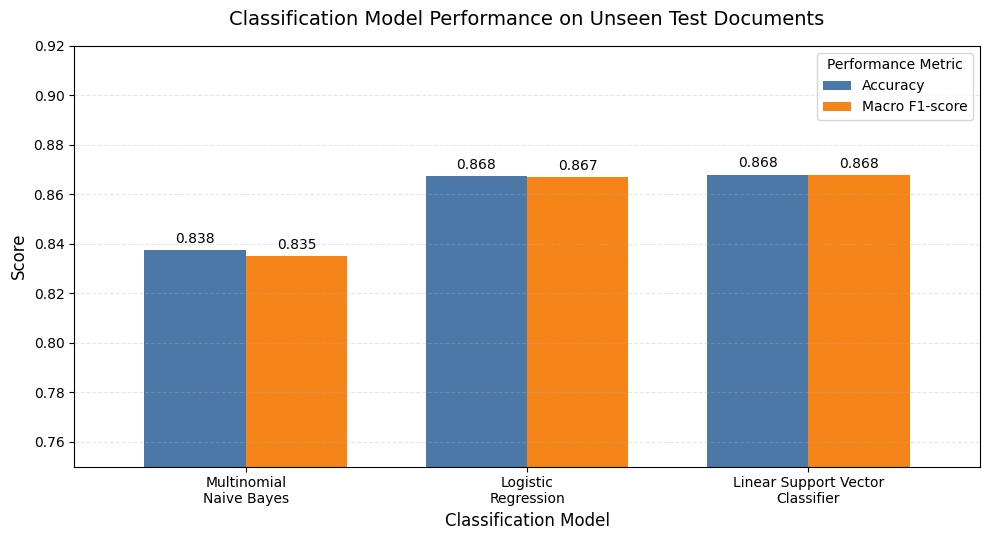

In [23]:
# Rebuild the comparison data directly from the latest stored results
comparison_plot_data = pd.DataFrame(
    {
        "Model": [
            "Multinomial\nNaive Bayes",
            "Logistic\nRegression",
            "Linear Support Vector\nClassifier"
        ],
        "Accuracy": [
            model_metrics[
                "Multinomial Naive Bayes"
            ]["Accuracy"],
            model_metrics[
                "Logistic Regression"
            ]["Accuracy"],
            model_metrics[
                "Linear Support Vector Classifier"
            ]["Accuracy"]
        ],
        "Macro F1-score": [
            model_metrics[
                "Multinomial Naive Bayes"
            ]["Macro F1"],
            model_metrics[
                "Logistic Regression"
            ]["Macro F1"],
            model_metrics[
                "Linear Support Vector Classifier"
            ]["Macro F1"]
        ]
    }
)

ax = comparison_plot_data.set_index(
    "Model"
).plot(
    kind="bar",
    figsize=(10, 5.5),
    color=[
        main_color,
        accent_color
    ],
    width=0.72
)

ax.set_title(
    "Classification Model Performance on Unseen Test Documents",
    pad=15
)

ax.set_xlabel("Classification Model")
ax.set_ylabel("Score")
ax.set_ylim(0.75, 0.92)

ax.set_xticklabels(
    comparison_plot_data["Model"],
    rotation=0
)

ax.legend(
    title="Performance Metric"
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.30
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3
    )

plt.tight_layout()
plt.show()

### Interpretation

The comparison shows that both linear classification models substantially outperformed the Multinomial Naive Bayes baseline.

- **Multinomial Naive Bayes** achieved an accuracy of 0.8375 and a macro F1-score of 0.8350.
- **Logistic Regression** achieved an accuracy of 0.8675 and a macro F1-score of 0.8671.
- **Linear Support Vector Classifier** achieved the strongest overall results, with an accuracy of 0.8680 and a macro F1-score of 0.8679.

The Linear Support Vector Classifier improved test accuracy by 3.05 percentage points compared with Multinomial Naive Bayes. Its advantage over Logistic Regression was only 0.05 percentage points, showing that the two linear models performed almost identically.

Based on its slightly higher accuracy and macro F1-score, the Linear Support Vector Classifier is selected for the remaining confusion-matrix analysis and test-document predictions.

## Confusion Matrix for the Selected Model

The Linear Support Vector Classifier produced the highest overall test accuracy and is selected for detailed error analysis.

A confusion matrix compares each document’s actual product category with the category predicted by the classifier. Values along the main diagonal represent correct classifications, while values outside the diagonal represent misclassified complaint documents.

This analysis helps identify which financial product categories are most frequently confused with one another.

Correctly classified documents: 1,736
Misclassified documents: 264
Test accuracy: 86.80%


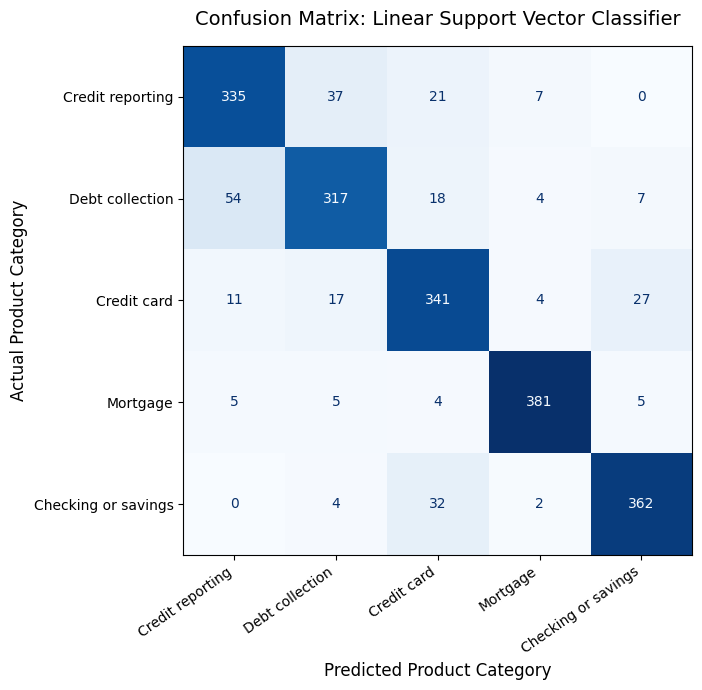

In [24]:
# Short labels used in the confusion matrix
confusion_labels = [
    "Credit reporting",
    "Debt collection",
    "Credit card",
    "Mortgage",
    "Checking or savings"
]

# Calculate the confusion matrix using the selected category order
linear_svc_confusion_matrix = confusion_matrix(
    y_test,
    linear_svc_predictions,
    labels=SELECTED_PRODUCTS
)

# Calculate overall correct and incorrect predictions
correct_predictions = np.trace(
    linear_svc_confusion_matrix
)

incorrect_predictions = (
    linear_svc_confusion_matrix.sum()
    - correct_predictions
)

print(
    f"Correctly classified documents: "
    f"{correct_predictions:,}"
)

print(
    f"Misclassified documents: "
    f"{incorrect_predictions:,}"
)

print(
    f"Test accuracy: "
    f"{correct_predictions / len(y_test):.2%}"
)

# Display the confusion matrix
fig, ax = plt.subplots(figsize=(9, 7))

confusion_display = ConfusionMatrixDisplay(
    confusion_matrix=linear_svc_confusion_matrix,
    display_labels=confusion_labels
)

confusion_display.plot(
    ax=ax,
    cmap="Blues",
    colorbar=False,
    values_format="d"
)

ax.set_title(
    "Confusion Matrix: Linear Support Vector Classifier",
    pad=15
)

ax.set_xlabel("Predicted Product Category")
ax.set_ylabel("Actual Product Category")

plt.xticks(
    rotation=35,
    ha="right"
)

plt.tight_layout()
plt.show()

### Interpretation

The Linear Support Vector Classifier correctly classified 1,736 of the 2,000 unseen complaint documents, producing an overall test accuracy of 86.80%.

Performance differed across product categories:

- **Mortgage** was classified most accurately, with 381 of 400 complaints correctly identified.
- **Checking or savings** had 362 correct predictions.
- **Credit card** had 341 correct predictions.
- **Credit reporting** had 335 correct predictions.
- **Debt collection** was the most difficult category, with 317 correct predictions.

The largest source of confusion occurred between **debt collection and credit reporting**. Fifty-four debt collection complaints were classified as credit reporting, while 37 credit reporting complaints were classified as debt collection. These categories may share language involving disputed accounts, credit reports, balances, validation, and collection activity.

Another noticeable overlap occurred between **credit card and checking or savings** complaints. Twenty-seven credit card complaints were classified as checking or savings, while 32 checking or savings complaints were classified as credit card. Both categories may discuss transactions, unauthorized charges, payments, balances, and account access.

Mortgage complaints were the most distinct category, with only 19 of 400 test documents misclassified.

## Most Common Misclassification Patterns

To examine the model's errors more closely, the off-diagonal confusion-matrix values are converted into a ranked table.

Each row represents an actual product category that was incorrectly assigned to another category. The error percentage is calculated relative to the 400 test documents in the actual category.

In [25]:
# Convert the confusion matrix into a labeled DataFrame
confusion_table = pd.DataFrame(
    linear_svc_confusion_matrix,
    index=confusion_labels,
    columns=confusion_labels
)

# Convert the matrix into a long-form table
misclassification_patterns = (
    confusion_table
    .rename_axis("Actual Category")
    .reset_index()
    .melt(
        id_vars="Actual Category",
        var_name="Predicted Category",
        value_name="Misclassified Documents"
    )
)

# Retain only incorrect predictions
misclassification_patterns = (
    misclassification_patterns.loc[
        misclassification_patterns[
            "Actual Category"
        ].ne(
            misclassification_patterns[
                "Predicted Category"
            ]
        )
        & misclassification_patterns[
            "Misclassified Documents"
        ].gt(0)
    ]
    .copy()
)

# Calculate each error as a percentage of its actual category
actual_category_totals = (
    confusion_table
    .sum(axis=1)
    .to_dict()
)

misclassification_patterns[
    "Percentage of Actual Category"
] = (
    misclassification_patterns.apply(
        lambda row:
        row["Misclassified Documents"]
        / actual_category_totals[
            row["Actual Category"]
        ]
        * 100,
        axis=1
    )
)

misclassification_patterns[
    "Percentage of Actual Category"
] = (
    misclassification_patterns[
        "Percentage of Actual Category"
    ]
    .round(2)
)

# Rank the ten most frequent errors
top_misclassification_patterns = (
    misclassification_patterns
    .sort_values(
        "Misclassified Documents",
        ascending=False
    )
    .head(10)
    .reset_index(drop=True)
)

display(top_misclassification_patterns)

,Actual Category,Predicted Category,Misclassified Documents,Percentage of Actual Category
0,Debt collection,Credit reporting,54,13.5000
1,Credit reporting,Debt collection,37,9.2500
2,Checking or savings,Credit card,32,8.0000
3,Credit card,Checking or savings,27,6.7500
4,Credit reporting,Credit card,21,5.2500
5,Debt collection,Credit card,18,4.5000
6,Credit card,Debt collection,17,4.2500
7,Credit card,Credit reporting,11,2.7500
8,Debt collection,Checking or savings,7,1.7500
9,Credit reporting,Mortgage,7,1.7500


## Predictions for Unseen Test Documents

The assignment requires using previously classified training documents to predict the categories of new documents. In this analysis, the 2,000 complaints in the test set were completely withheld from model training and therefore represent unseen documents.

This section presents a reproducible sample containing five correctly classified and five incorrectly classified test complaints. For each document, the table displays its actual category, predicted category, prediction result, decision margin, and a shortened narrative excerpt.

The decision margin represents the difference between the classifier's highest and second-highest decision scores. A larger margin indicates that the selected category was more clearly separated from the alternatives; it should not be interpreted as a probability.

In [26]:
# Obtain decision scores for every unseen test document
linear_svc_decision_scores = (
    linear_svc_model.decision_function(
        X_test_tfidf
    )
)

# Identify the two largest decision scores for each document
sorted_decision_scores = np.sort(
    linear_svc_decision_scores,
    axis=1
)

decision_margins = (
    sorted_decision_scores[:, -1]
    - sorted_decision_scores[:, -2]
)

# Build a detailed prediction table
test_predictions = test_data.copy()

test_predictions["predicted_product"] = (
    linear_svc_predictions
)

test_predictions["correct_prediction"] = (
    test_predictions["product"]
    .eq(test_predictions["predicted_product"])
)

test_predictions["decision_margin"] = (
    decision_margins
)

# Create readable short category labels
test_predictions["actual_category"] = (
    test_predictions["product"]
    .map(short_product_names)
)

test_predictions["predicted_category"] = (
    test_predictions["predicted_product"]
    .map(short_product_names)
)

# Create shortened document excerpts for display
test_predictions["narrative_excerpt"] = (
    test_predictions["narrative"]
    .str.replace(
        r"\s+",
        " ",
        regex=True
    )
    .str.strip()
    .str.slice(0, 240)
)

test_predictions["narrative_excerpt"] = (
    test_predictions["narrative_excerpt"]
    + "..."
)

# Select five correct and five incorrect predictions
correct_examples = (
    test_predictions.loc[
        test_predictions[
            "correct_prediction"
        ]
    ]
    .sample(
        n=5,
        random_state=RANDOM_STATE
    )
)

incorrect_examples = (
    test_predictions.loc[
        ~test_predictions[
            "correct_prediction"
        ]
    ]
    .sample(
        n=5,
        random_state=RANDOM_STATE
    )
)

prediction_examples = (
    pd.concat(
        [
            correct_examples,
            incorrect_examples
        ],
        ignore_index=True
    )
    .sample(
        frac=1,
        random_state=RANDOM_STATE
    )
    .reset_index(drop=True)
)

prediction_examples[
    "Prediction Result"
] = np.where(
    prediction_examples[
        "correct_prediction"
    ],
    "Correct",
    "Incorrect"
)

prediction_examples[
    "decision_margin"
] = prediction_examples[
    "decision_margin"
].round(4)

prediction_examples_display = (
    prediction_examples[
        [
            "complaint_id",
            "actual_category",
            "predicted_category",
            "Prediction Result",
            "decision_margin",
            "narrative_excerpt"
        ]
    ]
    .rename(
        columns={
            "complaint_id": "Complaint ID",
            "actual_category": "Actual Category",
            "predicted_category": "Predicted Category",
            "decision_margin": "Decision Margin",
            "narrative_excerpt": "Narrative Excerpt"
        }
    )
)

display(prediction_examples_display)

,Complaint ID,Actual Category,Predicted Category,Prediction Result,Decision Margin,Narrative Excerpt
0,13959404,Credit card,Checking or savings,Incorrect,0.0859,Accessing the Synchrony Bank website has become a regular challenge. Each time I attempt to log in to review my mont...
1,14146644,Credit reporting,Credit reporting,Correct,0.6682,XX/XX/XXXX {$1000.00} I asked for them to verify the accuracies of this account and it came back verifed. As I look ...
2,11897437,Checking or savings,Credit card,Incorrect,0.4337,"Around XXXX of XXXX, I woke up with my phone giving me notification s that my cash app card was being charged. It ha..."
3,8916075,Mortgage,Mortgage,Correct,0.4493,XX/XX/year> attempted to login to online account but website says is does not recognize my account. I tried to reset...
4,10081828,Debt collection,Credit card,Incorrect,0.0644,I contacted the company on XX/XX/XXXX when the court served me with court documentation. Explained to them that tran...
5,6526548,Checking or savings,Checking or savings,Correct,1.3559,I've had a checking and savings at Wells Fargo for over 22 years. I've never bounced a check or gone overdraft that ...
6,8352133,Debt collection,Checking or savings,Incorrect,0.2033,Did not open account with this complaint...
7,10172093,Credit card,Credit card,Correct,0.3878,For 10 years Ive banked with Chase and been a private client for most of them without a problem. I have been a victi...
8,10021511,Mortgage,Mortgage,Correct,2.2104,"On XX/XX/XXXX, I sent an email to MortgagePros, requesting the termination of my loan application and the transfer o..."
9,10044499,Debt collection,Credit reporting,Incorrect,0.0584,"XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXXXXXX XXXX TX XXXXXXXX XXXX XXXX XXXX XXXXXXXX fraud, Claims true identity fra..."


### Interpretation

The examples demonstrate how the selected classifier assigns product categories to complaint documents that were not used during training.

Several correct predictions contain highly category-specific language. For example, complaints describing a mortgage application or loan termination were correctly classified as mortgage, while narratives explicitly discussing checking and savings accounts were correctly assigned to checking or savings.

The incorrect predictions generally involve overlapping financial concepts. A credit card complaint mentioning the Synchrony Bank website was classified as checking or savings, while a checking or savings complaint involving a Cash App card charge was classified as credit card. Debt collection complaints were also confused with credit reporting, credit card, and checking or savings when their narratives discussed accounts, transactions, or disputed records.

Most incorrect examples have relatively small decision margins, indicating that the classifier found two or more categories similarly plausible. The correctly classified examples generally show larger margins when their language strongly identifies a particular financial product.

These results directly demonstrate the assignment objective: previously classified training documents were used to predict the categories of new, withheld test documents.

## Influential Words and Phrases in the Selected Model

The Linear Support Vector Classifier assigns a coefficient to every TF-IDF word or phrase for each product category.

A larger positive coefficient indicates that the presence of a feature pushes the model more strongly toward a particular category. Examining these coefficients helps explain how the selected classifier makes its predictions.

The following table presents the twelve most influential words or phrases for each financial product category.

In [27]:
# Number of influential model features displayed per category
TOP_MODEL_FEATURES = 12

model_feature_records = []

# The class order is taken directly from the trained classifier
for class_index, product in enumerate(
    linear_svc_model.classes_
):
    class_coefficients = (
        linear_svc_model.coef_[class_index]
    )

    # Exclude features containing no alphabetic characters
    valid_coefficients = class_coefficients.copy()

    valid_coefficients[
        ~feature_has_letters
    ] = -np.inf

    top_feature_indexes = np.argsort(
        valid_coefficients
    )[-TOP_MODEL_FEATURES:][::-1]

    for rank, feature_index in enumerate(
        top_feature_indexes,
        start=1
    ):
        model_feature_records.append(
            {
                "Product Category": product,
                "Rank": rank,
                "Feature": feature_names[
                    feature_index
                ],
                "Coefficient": class_coefficients[
                    feature_index
                ]
            }
        )

model_features = pd.DataFrame(
    model_feature_records
)

model_features["Short Category"] = (
    model_features["Product Category"]
    .map(short_product_names)
)

# Create a compact comparison table
model_features_table = (
    model_features
    .pivot(
        index="Rank",
        columns="Short Category",
        values="Feature"
    )
    .reindex(
        columns=[
            "Credit reporting",
            "Debt collection",
            "Credit card",
            "Mortgage",
            "Checking or savings"
        ]
    )
)

model_features_table.columns.name = (
    "Product Category"
)

display(model_features_table)

Product Category,Credit reporting,Debt collection,Credit card,Mortgage,Checking or savings
Rank,,,,,
1,experian,debt,card,mortgage,bank
2,inquiries,collection,credit card,loan,funds
3,transunion,collections,synchrony,escrow,money
4,equifax,owed,capital,home,chime
5,inquiry,owe,comenity,foreclosure,debit card
6,accounts,systems,cards,modification,debit
7,loans,collector,citi,heloc,checking account
8,inaccuracies,medical,rewards,servicing,overdraft
9,fcra,transworld,discover,insurance,checking


### Interpretation

The influential model features provide a clear explanation of how the Linear Support Vector Classifier distinguishes the five product categories.

- **Credit reporting** predictions are strongly influenced by credit bureau names such as `Experian`, `TransUnion`, and `Equifax`, together with terms such as `inquiries`, `inaccuracies`, `FCRA`, and `remove`.
- **Debt collection** predictions emphasize `debt`, `collection`, `collector`, `owed`, and company-related terms such as `Transworld` and `LVNV`.
- **Credit card** predictions are associated with `card`, `credit card`, `charges`, and issuer names such as `Synchrony`, `Capital`, `Discover`, and `American Express`.
- **Mortgage** predictions rely on highly specific terms including `mortgage`, `loan`, `escrow`, `foreclosure`, `modification`, `servicing`, and `forbearance`.
- **Checking or savings** predictions emphasize `bank`, `funds`, `debit card`, `checking account`, `overdraft`, `branch`, and `transactions`.

These features are consistent with the expected language of each financial product. Their interpretability also provides evidence that the classifier is learning meaningful product-related patterns rather than relying on unrelated characteristics.

## Visualization of Influential Model Features

The following visualizations display the twelve strongest positive coefficients learned by the selected classifier for each product category.

Longer bars indicate that a word or phrase contributes more strongly toward predicting the corresponding category. Each product is displayed separately to preserve readable feature labels and make category-specific patterns easier to compare.

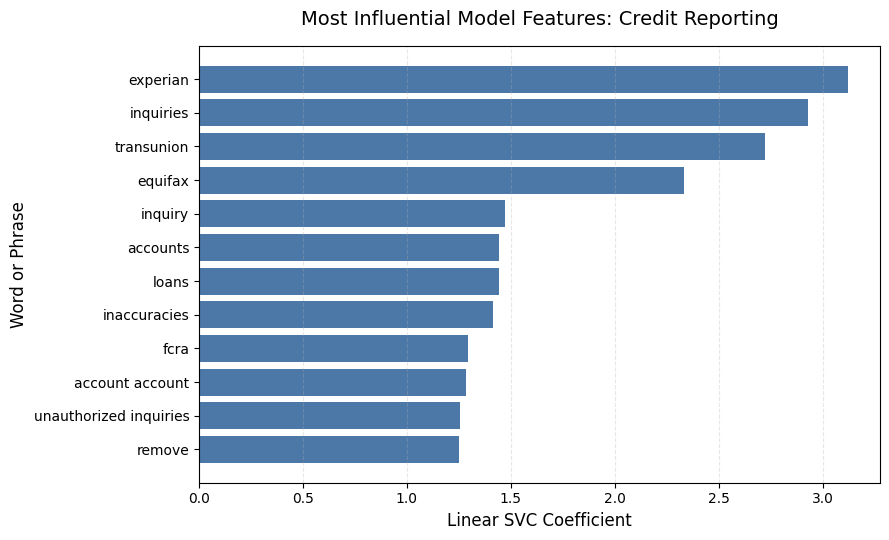

In [28]:
credit_reporting_model_features = (
    model_features.loc[
        model_features["Product Category"].eq(
            "Credit reporting or other personal consumer reports"
        )
    ]
    .sort_values(
        "Coefficient",
        ascending=True
    )
)

fig, ax = plt.subplots(figsize=(9, 5.5))

ax.barh(
    credit_reporting_model_features["Feature"],
    credit_reporting_model_features["Coefficient"],
    color=main_color
)

ax.set_title(
    "Most Influential Model Features: Credit Reporting",
    pad=15
)

ax.set_xlabel("Linear SVC Coefficient")
ax.set_ylabel("Word or Phrase")

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.30
)

plt.tight_layout()
plt.show()

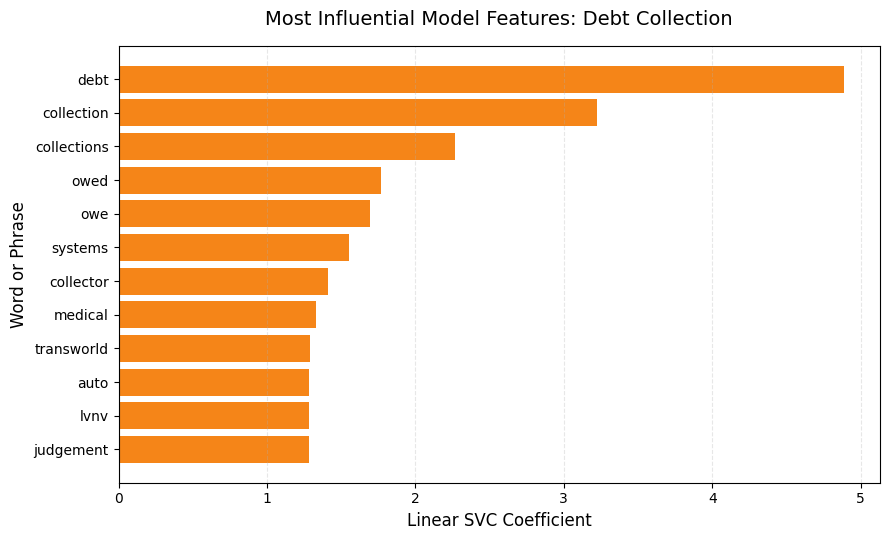

In [29]:
debt_collection_model_features = (
    model_features.loc[
        model_features["Product Category"].eq(
            "Debt collection"
        )
    ]
    .sort_values(
        "Coefficient",
        ascending=True
    )
)

fig, ax = plt.subplots(figsize=(9, 5.5))

ax.barh(
    debt_collection_model_features["Feature"],
    debt_collection_model_features["Coefficient"],
    color=accent_color
)

ax.set_title(
    "Most Influential Model Features: Debt Collection",
    pad=15
)

ax.set_xlabel("Linear SVC Coefficient")
ax.set_ylabel("Word or Phrase")

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.30
)

plt.tight_layout()
plt.show()

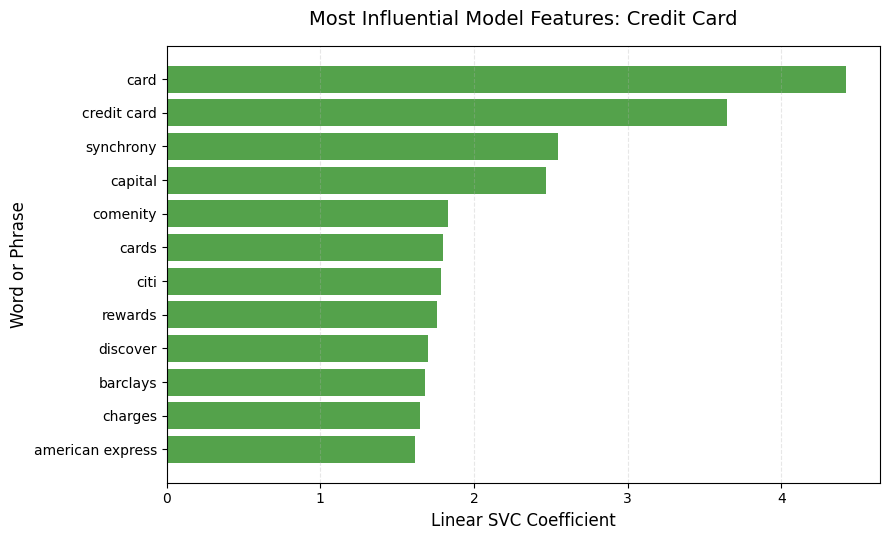

In [30]:
credit_card_model_features = (
    model_features.loc[
        model_features["Product Category"].eq(
            "Credit card"
        )
    ]
    .sort_values(
        "Coefficient",
        ascending=True
    )
)

fig, ax = plt.subplots(figsize=(9, 5.5))

ax.barh(
    credit_card_model_features["Feature"],
    credit_card_model_features["Coefficient"],
    color=green_color
)

ax.set_title(
    "Most Influential Model Features: Credit Card",
    pad=15
)

ax.set_xlabel("Linear SVC Coefficient")
ax.set_ylabel("Word or Phrase")

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.30
)

plt.tight_layout()
plt.show()

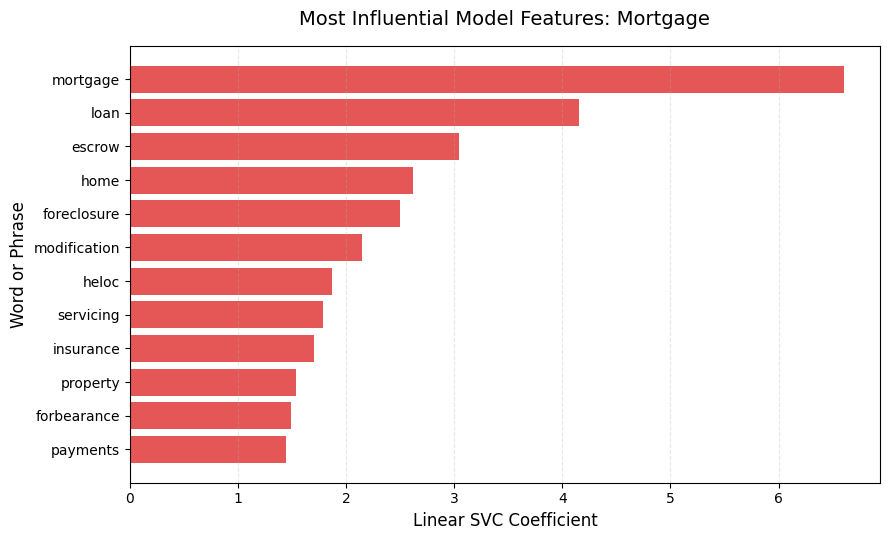

In [31]:
mortgage_model_features = (
    model_features.loc[
        model_features["Product Category"].eq(
            "Mortgage"
        )
    ]
    .sort_values(
        "Coefficient",
        ascending=True
    )
)

fig, ax = plt.subplots(figsize=(9, 5.5))

ax.barh(
    mortgage_model_features["Feature"],
    mortgage_model_features["Coefficient"],
    color=red_color
)

ax.set_title(
    "Most Influential Model Features: Mortgage",
    pad=15
)

ax.set_xlabel("Linear SVC Coefficient")
ax.set_ylabel("Word or Phrase")

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.30
)

plt.tight_layout()
plt.show()

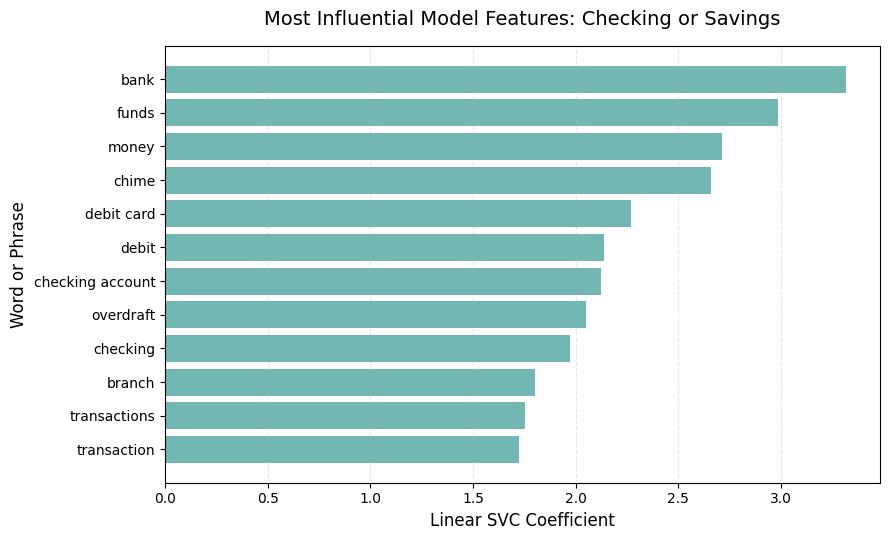

In [32]:
checking_savings_model_features = (
    model_features.loc[
        model_features["Product Category"].eq(
            "Checking or savings account"
        )
    ]
    .sort_values(
        "Coefficient",
        ascending=True
    )
)

fig, ax = plt.subplots(figsize=(9, 5.5))

ax.barh(
    checking_savings_model_features["Feature"],
    checking_savings_model_features["Coefficient"],
    color=palette[4]
)

ax.set_title(
    "Most Influential Model Features: Checking or Savings",
    pad=15
)

ax.set_xlabel("Linear SVC Coefficient")
ax.set_ylabel("Word or Phrase")

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.30
)

plt.tight_layout()
plt.show()

## Overall Findings and Research Question Answer

This section summarizes the complete document-classification analysis and directly answers the research question.

The summary combines the dataset size, training-test split, TF-IDF representation, best-performing classifier, test accuracy, category-level performance, and most common classification error.

In [33]:
# Identify the best model using test accuracy
best_model_name = max(
    model_metrics,
    key=lambda model_name:
    model_metrics[model_name]["Accuracy"]
)

best_model_accuracy = (
    model_metrics[best_model_name]["Accuracy"]
)

best_model_macro_f1 = (
    model_metrics[best_model_name]["Macro F1"]
)

# Calculate category-level recall from the selected confusion matrix
category_recall_values = (
    np.diag(linear_svc_confusion_matrix)
    / linear_svc_confusion_matrix.sum(axis=1)
)

category_recall_summary = pd.Series(
    category_recall_values,
    index=confusion_labels
)

best_classified_category = (
    category_recall_summary.idxmax()
)

most_difficult_category = (
    category_recall_summary.idxmin()
)

# Identify the most common off-diagonal error
largest_error = (
    top_misclassification_patterns.iloc[0]
)

overall_findings = pd.DataFrame(
    {
        "Analysis Measure": [
            "Total classified documents",
            "Training documents",
            "Unseen test documents",
            "Product categories",
            "TF-IDF features",
            "Best-performing model",
            "Best-model accuracy",
            "Best-model macro F1-score",
            "Correct test predictions",
            "Incorrect test predictions",
            "Best-classified category",
            "Most difficult category",
            "Most common classification error"
        ],
        "Result": [
            f"{len(model_data):,}",
            f"{len(train_data):,}",
            f"{len(test_data):,}",
            f"{model_data['product'].nunique():,}",
            f"{X_train_tfidf.shape[1]:,}",
            best_model_name,
            f"{best_model_accuracy:.2%}",
            f"{best_model_macro_f1:.4f}",
            f"{correct_predictions:,}",
            f"{incorrect_predictions:,}",
            (
                f"{best_classified_category} "
                f"({category_recall_summary.max():.2%} recall)"
            ),
            (
                f"{most_difficult_category} "
                f"({category_recall_summary.min():.2%} recall)"
            ),
            (
                f"{largest_error['Actual Category']} → "
                f"{largest_error['Predicted Category']} "
                f"({largest_error['Misclassified Documents']:,} documents)"
            )
        ]
    }
)

display(overall_findings)

,Analysis Measure,Result
0,Total classified documents,"10,000"
1,Training documents,"8,000"
2,Unseen test documents,"2,000"
3,Product categories,5
4,TF-IDF features,"30,000"
5,Best-performing model,Linear Support Vector Classifier
6,Best-model accuracy,86.80%
7,Best-model macro F1-score,0.8679
8,Correct test predictions,"1,736"
9,Incorrect test predictions,264


### Key Findings

The analysis demonstrates that consumer complaint narratives can be classified into financial product categories with strong accuracy using TF-IDF text features and supervised machine-learning algorithms.

The Linear Support Vector Classifier produced the best overall result, correctly classifying 1,736 of the 2,000 unseen test documents. This corresponds to an accuracy of 86.80% and a macro F1-score of 0.8679. Logistic Regression performed almost identically, while Multinomial Naive Bayes provided a lower but still useful baseline.

Mortgage complaints were the easiest to identify, with 381 of 400 test documents classified correctly. Their vocabulary included highly distinctive terms such as `mortgage`, `loan`, `escrow`, `foreclosure`, `modification`, and `servicing`.

Debt collection was the most difficult category. The most common error occurred when debt collection complaints were predicted as credit reporting. These categories frequently share language concerning disputed accounts, balances, collection activity, credit reports, validation, and inaccurate records.

Credit card and checking or savings complaints also overlapped because both frequently discuss transactions, charges, payments, account access, debit cards, and unauthorized activity.

### Answer to the Research Question

Machine-learning classifiers can use consumer complaint narratives to predict the financial product category of previously unseen complaints with strong performance. Among the three evaluated models, the Linear Support Vector Classifier produced the best result, achieving 86.80% test accuracy and a macro F1-score of 0.8679 across the five balanced product categories.

The results also show that classification performance depends on how distinctive each category's language is. Categories with specialized vocabulary, particularly mortgage, were identified more accurately than categories with overlapping terminology, particularly debt collection and credit reporting.

## Limitations and Future Improvements

Although the classification results are strong, several limitations should be considered when interpreting the findings.

### Limitations

1. **Restricted product categories:**  
   The analysis includes only five financial product categories. The complete CFPB database contains additional products and services, so the model does not represent the full range of consumer complaints.

2. **Balanced sample:**  
   Exactly 2,000 documents were selected from each category. This improves model comparison but does not reflect the natural frequency of product categories in the complete CFPB database.

3. **Published narratives only:**  
   The dataset includes only complaints for which a public consumer narrative was available. Complaints without published narratives may differ from those included in the analysis.

4. **Existing CFPB labels:**  
   The product categories are treated as correct training labels. Any inconsistencies or errors in the original classifications may affect model performance.

5. **Overlapping financial language:**  
   Some complaints involve multiple financial products or use terminology shared across categories. This was especially noticeable between debt collection and credit reporting, as well as between credit card and checking or savings complaints.

6. **Company and brand names:**  
   The model learned company names such as `Experian`, `Synchrony`, `Chime`, and `American Express`. These names can be informative, but they may also reduce performance when complaints involve unfamiliar companies.

7. **Limited model tuning:**  
   The models were trained using reasonable fixed settings rather than an extensive hyperparameter search. Additional tuning could improve performance.

8. **Single dataset snapshot:**  
   The analysis uses complaints received within a fixed period and sampled from one downloaded CFPB database snapshot. Language patterns and financial products may change over time.

### Future Improvements

Future work could expand the analysis by:

- Including additional CFPB product categories
- Evaluating the model on naturally imbalanced complaint data
- Using cross-validation and systematic hyperparameter tuning
- Comparing word-level TF-IDF with character-level features
- Testing transformer-based language models
- Removing or generalizing company names to measure their influence
- Examining model performance across time periods
- Evaluating newly submitted complaints collected after the training period
- Developing an automated system that routes new complaints to the appropriate department

These improvements could produce a more generalizable classification system and provide a stronger evaluation of performance in a real-world complaint-routing environment.

## Conclusion

This project developed a multiclass document-classification system using 10,000 consumer complaint narratives from the Consumer Financial Protection Bureau Consumer Complaint Database. Each narrative was already classified according to its associated financial product, allowing the documents to be divided into labeled training and unseen test sets.

The complaint narratives were transformed into 30,000 TF-IDF unigram and bigram features. Three classification algorithms were then trained and compared:

- Multinomial Naive Bayes
- Logistic Regression
- Linear Support Vector Classifier

The Linear Support Vector Classifier produced the strongest overall performance, achieving an accuracy of **86.80%** and a macro F1-score of **0.8679** on 2,000 previously unseen complaint documents. Logistic Regression performed almost identically, while Multinomial Naive Bayes provided a lower but useful baseline.

Mortgage complaints were classified most accurately because they contained highly distinctive vocabulary related to loans, escrow, foreclosure, servicing, and modification. Debt collection was the most difficult category, particularly when its language overlapped with credit reporting. Credit card and checking or savings complaints also showed some confusion because both frequently discussed transactions, charges, payments, and unauthorized activity.

The influential-feature analysis showed that the selected classifier learned meaningful product-related language rather than relying on arbitrary patterns. Examples of withheld test documents further demonstrated how previously classified training documents can be used to predict the categories of new documents.

Overall, the results answer the research question by showing that TF-IDF features combined with linear machine-learning classifiers can categorize previously unseen consumer financial complaints with strong and interpretable performance.

## References

Consumer Financial Protection Bureau. (n.d.). *Consumer Complaint Database*.  
https://www.consumerfinance.gov/data-research/consumer-complaints/

Consumer Financial Protection Bureau. (n.d.). *Consumer Complaint Database* [Data set]. Retrieved July 10, 2026, from  
https://files.consumerfinance.gov/ccdb/complaints.csv.zip

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.

Scikit-learn developers. (n.d.). *Working with text data*.  
https://scikit-learn.org/stable/tutorial/text_analytics/working_with_text_data.html

Scikit-learn developers. (n.d.). *TfidfVectorizer*.  
https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html

Scikit-learn developers. (n.d.). *LinearSVC*.  
https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html

Scikit-learn developers. (n.d.). *LogisticRegression*.  
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

Scikit-learn developers. (n.d.). *MultinomialNB*.  
https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.MultinomialNB.html